# Lyon PT Accessibility — Commuter-Weighted Scenario Selection

**Purpose.** Pick a Kelheim-equivalent scenario for Paper 1 (rural DRT ridepooling) by quantifying **per-commune PT accessibility**, weighted by commuter flow. Recreates the HEART-2025 methodology (slides 21–22) for the Lyon region.

**Three independent signals per commune:**
1. **PT Accessibility Rating** — commuter-weighted `min(1, car_time / pt_time_no_wait)`. Fair to PT: we evaluate at the *best departure time* (no initial wait at the stop).
2. **Daytime service frequency** — trips/hour at commune stops during 07:00–19:00 weekdays.
3. **Connectivity index** — fraction of destinations reachable in 60 min by PT vs by car.

A DRT target is a commune that is **bad on all three** yet has **real commute volume**.

> **Dependencies.** r5py + Java 21+ (SDKMAN provides 22). OSM Rhône-Alpes + regional GTFS feeds — fetch with `python ../download_lyon_data.py --scenario-selection`.

## 0. Setup

In [1]:
# Run once if r5py isn't installed in this kernel's venv:
# %pip install -q r5py

%matplotlib inline

from pathlib import Path
import datetime as dt
import zipfile
from math import radians, cos, sin, asin, sqrt

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

HERE = Path.cwd()
DATA = HERE / "data"
CACHE = HERE / "cache"
CACHE.mkdir(exist_ok=True)

PIPELINE_DATA = HERE.parent / "data"
GTFS_DIR = PIPELINE_DATA / "gtfs_lyon"
OSM_PATH = PIPELINE_DATA / "osm_lyon" / "rhone-alpes-220101.osm.pbf"

LYON_DEPTS = {"01", "38", "42", "69"}
LYON_CENTRE_LON, LYON_CENTRE_LAT = 4.8590, 45.7607   # Part-Dieu

PEAK_DATE = dt.date(2026, 4, 21)                 # Tuesday
PEAK_START = dt.datetime.combine(PEAK_DATE, dt.time(7, 0))
PEAK_WINDOW = dt.timedelta(minutes=120)          # 07:00–09:00 trial-departure window
PT_PERCENTILES = [1]                             # near-minimum → 'no initial wait' (best departure time)

def hkm(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, (lon1, lat1, lon2, lat2))
    a = sin((lat2-lat1)/2)**2 + cos(lat1)*cos(lat2)*sin((lon2-lon1)/2)**2
    return 2 * 6371 * asin(sqrt(a))

print(f"data: {DATA.exists()}  |  gtfs: {GTFS_DIR.exists()}  |  osm: {OSM_PATH.exists()}")

data: True  |  gtfs: True  |  osm: True


## 1. Load MOBPRO + commune geometries

INSEE MOBPRO 2022: per-worker origin commune → work commune → mode. We keep flows where both endpoints are in the four Lyon départements. TRANS codes (float): 1=WFH, 2=walk, 3=bike, 4=motorbike, 5=car, 6=PT.

In [2]:
mobpro = pd.read_parquet(DATA / "RP2022_mobpro.parquet")
communes = gpd.read_file(DATA / "communes-100m.geojson")

communes["dept"] = communes["code"].str[:2]
lyon_communes = communes[communes["dept"].isin(LYON_DEPTS)].copy()

m = mobpro.copy()
m["o_dept"] = m["COMMUNE"].astype(str).str[:2]
m["d_dept"] = m["DCLT"].astype(str).str[:2]
m = m[m["o_dept"].isin(LYON_DEPTS) & m["d_dept"].isin(LYON_DEPTS)]
print(f"Lyon-dépts commuters: {m['IPONDI'].sum():,.0f}  |  communes: {len(lyon_communes):,}")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\VWAUCCY\\dev\\msf\\projects\\Dissertation\\matsim_scenarios\\eqasim-france\\scenario-selection\\data\\RP2022_mobpro.parquet'

## 2. Build OD flow table + per-commune aggregates

For each commune we need both directions of its commute fingerprint. Intra-commune self-loops dropped.

In [ ]:
ACTIVE_MODES = {2.0, 3.0, 4.0, 5.0, 6.0}
m_active = m[m["TRANS"].isin(ACTIVE_MODES)].copy()
m_active["COMMUNE"] = m_active["COMMUNE"].astype(str)
m_active["DCLT"]    = m_active["DCLT"].astype(str)

od = (m_active.groupby(["COMMUNE","DCLT","TRANS"], as_index=False)["IPONDI"].sum()
      .rename(columns={"COMMUNE":"origin","DCLT":"dest","TRANS":"mode","IPONDI":"weight"}))
od = od[od["origin"] != od["dest"]].copy()
od_mode = od.pivot_table(index=["origin","dest"], columns="mode", values="weight", fill_value=0.0)
od_mode.columns = [f"m{int(c)}" for c in od_mode.columns]
od_mode["total"] = od_mode.sum(axis=1)
od_mode["car"]   = od_mode.get("m5", 0.0) + od_mode.get("m4", 0.0)
od_mode["car_share"] = od_mode["car"] / od_mode["total"]
od_mode = od_mode.reset_index()
print(f"OD pairs: {len(od_mode):,}  |  commuters: {od_mode['total'].sum():,.0f}")

OD pairs: 54,485  |  commuters: 1,420,934


In [ ]:
# Per-commune aggregates (needed for pre-filtering r5py endpoints in §4)
lc_ctr = lyon_communes.to_crs("EPSG:4326").geometry.centroid
lyon_communes["lon"] = lc_ctr.x
lyon_communes["lat"] = lc_ctr.y
lyon_communes["dist_to_lyon_km"] = lyon_communes.apply(lambda r: hkm(LYON_CENTRE_LON, LYON_CENTRE_LAT, r["lon"], r["lat"]), axis=1)

outflow = od_mode.groupby("origin", as_index=False).agg(out_total=("total","sum"), out_car=("car","sum"))
inflow  = od_mode.groupby("dest",   as_index=False).agg(in_total=("total","sum"),  in_car=("car","sum"))
lyon_dests = [f"6938{i}" for i in range(1,10)] + ["69266"]
to_lyon = od_mode[od_mode["dest"].isin(lyon_dests)].groupby("origin", as_index=False)["total"].sum().rename(columns={"total":"to_lyon"})

lyon_communes = lyon_communes.merge(outflow.rename(columns={"origin":"code"}), on="code", how="left")
lyon_communes = lyon_communes.merge(inflow.rename(columns={"dest":"code"}),    on="code", how="left")
lyon_communes = lyon_communes.merge(to_lyon.rename(columns={"origin":"code"}),  on="code", how="left")
lyon_communes["total_flow"] = lyon_communes[["out_total","in_total"]].fillna(0).sum(axis=1)
lyon_communes["car_share"]  = (lyon_communes["out_car"].fillna(0) + lyon_communes["in_car"].fillna(0)) / lyon_communes["total_flow"].replace(0, np.nan)
lyon_communes["io_ratio"]   = lyon_communes["out_total"].fillna(0) / lyon_communes["in_total"].replace(0, np.nan)
lyon_communes["lyon_share"] = lyon_communes["to_lyon"].fillna(0) / lyon_communes["out_total"].replace(0, np.nan)
print(f"per-commune aggregates computed  |  {len(lyon_communes):,} communes")

per-commune aggregates computed  |  1,498 communes


/tmp/ipykernel_541431/2164049131.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lc_ctr = lyon_communes.to_crs("EPSG:4326").geometry.centroid


## 3. Rail-station proximity per commune

Distance from each commune centroid to the nearest rail stop across all GTFS feeds. Filters on `route_type` in the rail family (2, 100–117 extended).

In [ ]:
RAIL_ROUTE_TYPES = {2} | set(range(100, 118))

def gtfs_rail_stops(gtfs_zip: Path):
    try:
        with zipfile.ZipFile(gtfs_zip) as zf:
            if not {"stops.txt","routes.txt","trips.txt","stop_times.txt"}.issubset(set(zf.namelist())):
                return None
            routes = pd.read_csv(zf.open("routes.txt"), low_memory=False)
            trips  = pd.read_csv(zf.open("trips.txt"), low_memory=False)
            stimes = pd.read_csv(zf.open("stop_times.txt"), usecols=["trip_id","stop_id"], low_memory=False)
            stops  = pd.read_csv(zf.open("stops.txt"), low_memory=False)
        rail_routes = routes[routes["route_type"].isin(RAIL_ROUTE_TYPES)]
        if rail_routes.empty: return None
        rail_trips = trips[trips["route_id"].isin(rail_routes["route_id"])]
        rail_stop_ids = stimes[stimes["trip_id"].isin(rail_trips["trip_id"])]["stop_id"].unique()
        rs = stops[stops["stop_id"].isin(rail_stop_ids)][["stop_id","stop_name","stop_lat","stop_lon"]].copy()
        rs["feed"] = gtfs_zip.name
        return rs
    except Exception as e:
        print(f"  warn: {gtfs_zip.name}: {e}")
        return None

if GTFS_DIR.exists():
    rail_dfs = [df for df in (gtfs_rail_stops(p) for p in sorted(GTFS_DIR.glob("*.zip"))) if df is not None]
    rail = pd.concat(rail_dfs, ignore_index=True) if rail_dfs else pd.DataFrame()
    rail_gdf = gpd.GeoDataFrame(rail, geometry=gpd.points_from_xy(rail["stop_lon"], rail["stop_lat"]), crs="EPSG:4326").to_crs("EPSG:2154") if not rail.empty else None
    print(f"Rail stops: {len(rail_gdf):,}")
else:
    rail_gdf = None
    print("GTFS missing.")

if rail_gdf is not None:
    lc2154 = lyon_communes.to_crs("EPSG:2154").copy()
    lc2154["centroid"] = lc2154.geometry.centroid
    centroids = gpd.GeoDataFrame(lc2154[["code"]], geometry=lc2154["centroid"], crs="EPSG:2154")
    nearest = gpd.sjoin_nearest(centroids, rail_gdf[["geometry"]], distance_col="dist_m")
    commune_rail = nearest.groupby("code", as_index=False)["dist_m"].min()
    commune_rail["dist_to_rail_km"] = commune_rail["dist_m"] / 1000.0
    lyon_communes = lyon_communes.merge(commune_rail[["code","dist_to_rail_km"]], on="code", how="left")
    print(lyon_communes.sort_values("dist_to_rail_km", ascending=False)[["code","nom","dist_to_rail_km"]].head(5).to_string(index=False))

Rail stops: 4,564
 code                        nom  dist_to_rail_km
38522                Valjouffrey        34.805416
38253             Les Deux Alpes        31.631733
38237                     Mizoën        29.310666
38375 Saint-Christophe-en-Oisans        29.017751
38469       La Salette-Fallavaux        28.687302


## 3b. PT service frequency per commune

Trips departing from stops within the commune polygon during **07:00–19:00** weekdays. Summed across feeds, divided by 12 → average daytime trips/hour. A commune with 10 trips/hr has a usable network; 0.5 trips/hr is PT-absent.

In [ ]:
def daytime_trips_per_stop(gtfs_zip: Path, tw_start="07:00:00", tw_end="19:00:00"):
    try:
        with zipfile.ZipFile(gtfs_zip) as zf:
            names = set(zf.namelist())
            if not {"stops.txt","stop_times.txt","trips.txt","calendar.txt"}.issubset(names): return None
            stops  = pd.read_csv(zf.open("stops.txt"), low_memory=False)
            stimes = pd.read_csv(zf.open("stop_times.txt"), usecols=["trip_id","stop_id","departure_time"], low_memory=False)
            trips  = pd.read_csv(zf.open("trips.txt"),  usecols=["trip_id","service_id"], low_memory=False)
            cal    = pd.read_csv(zf.open("calendar.txt"), low_memory=False)
        tue = cal[cal["tuesday"] == 1]["service_id"]
        trips = trips[trips["service_id"].isin(tue)]
        stimes = stimes[stimes["trip_id"].isin(trips["trip_id"])]
        peak = stimes[(stimes["departure_time"] >= tw_start) & (stimes["departure_time"] < tw_end)]
        counts = peak.groupby("stop_id").size().rename("trips").reset_index()
        counts["stop_id"] = counts["stop_id"].astype(str)
        stops["stop_id"]  = stops["stop_id"].astype(str)
        out = stops[["stop_id","stop_lat","stop_lon"]].merge(counts, on="stop_id", how="inner")
        return out
    except Exception as e:
        print(f"  warn: {gtfs_zip.name}: {e}")
        return None

if GTFS_DIR.exists():
    fdfs = [df for df in (daytime_trips_per_stop(p) for p in sorted(GTFS_DIR.glob("*.zip"))) if df is not None]
    freq = pd.concat(fdfs, ignore_index=True) if fdfs else pd.DataFrame()
    if not freq.empty:
        freq_gdf = gpd.GeoDataFrame(freq, geometry=gpd.points_from_xy(freq["stop_lon"], freq["stop_lat"]), crs="EPSG:4326").to_crs("EPSG:2154")
        joined = gpd.sjoin(freq_gdf, lyon_communes.to_crs("EPSG:2154")[["code","geometry"]], how="left", predicate="within")
        commune_freq = joined.dropna(subset=["code"]).groupby("code", as_index=False)["trips"].sum()
        commune_freq["daytime_trips_per_hour"] = commune_freq["trips"] / 12.0
        lyon_communes = lyon_communes.merge(commune_freq[["code","daytime_trips_per_hour"]], on="code", how="left")
        lyon_communes["daytime_trips_per_hour"] = lyon_communes["daytime_trips_per_hour"].fillna(0.0)
        print(lyon_communes.sort_values("daytime_trips_per_hour", ascending=False)[["code","nom","daytime_trips_per_hour"]].head(5).to_string(index=False))
    else:
        print("No frequency data parsed.")
else:
    print("GTFS missing.")

 code                    nom  daytime_trips_per_hour
69123                   Lyon            11885.916667
69266           Villeurbanne             2333.000000
69259             Vénissieux             1977.666667
69383 Lyon 3e Arrondissement             1882.416667
69389 Lyon 9e Arrondissement             1838.666667


### 3c. Sanitize GTFS feeds for r5py

r5py's R5 router rejects empty GTFS tables (header-only). We copy each feed to `data/gtfs_clean/clean_<name>.zip` and strip empty optional tables. The `clean_` prefix avoids basename collisions with r5py's own cache dir (which symlinks feeds by basename).

In [ ]:
GTFS_CLEAN = HERE / "data" / "gtfs_clean"
GTFS_CLEAN.mkdir(parents=True, exist_ok=True)

OPTIONAL_TABLES = {"frequencies.txt","transfers.txt","shapes.txt","fare_attributes.txt",
                   "fare_rules.txt","pathways.txt","levels.txt","translations.txt",
                   "attributions.txt","feed_info.txt"}

def is_empty(content: bytes) -> bool:
    lines = [l for l in content.decode("utf-8", errors="replace").splitlines() if l.strip()]
    return len(lines) <= 1

def sanitize_feed(src: Path, dst: Path):
    if dst.exists() and dst.stat().st_mtime >= src.stat().st_mtime:
        return dst, []
    dropped = []
    with zipfile.ZipFile(src) as zin, zipfile.ZipFile(dst, "w", zipfile.ZIP_DEFLATED) as zout:
        for name in zin.namelist():
            data = zin.read(name)
            if name in OPTIONAL_TABLES and is_empty(data):
                dropped.append(name); continue
            zout.writestr(name, data)
    return dst, dropped

clean_feeds = []
for src in sorted(GTFS_DIR.glob("*.zip")):
    dst = GTFS_CLEAN / f"clean_{src.name}"
    out, dropped = sanitize_feed(src, dst)
    clean_feeds.append(str(out))
    tag = f"(dropped {dropped})" if dropped else "(ok)"
    print(f"  {src.name:35s} -> {tag}")
print(f"\nfeed count: {len(clean_feeds)}")

  BUL-GTFS.zip                        -> (ok)
  express.gtfs.zip                    -> (ok)
  lyon_tcl.zip                        -> (ok)
  medias.zip                          -> (ok)
  oura.gtfs.zip                       -> (ok)
  sncf-tgv-intercite-ter.gtfs.zip     -> (ok)
  stas.gtfs.zip                       -> (ok)

feed count: 7


## 4. Travel-time OD matrix (r5py)

**Scoping.** We first apply a *loose* pre-filter (distance, car share, flow, multi-directional, Lyon-bound) to identify candidate communes — typically 30–60. For each candidate we include its top-15 flow partners (both inbound and outbound). Plus Lyon arrondissements. Total endpoints ≈ 150–300.

**PT time — no initial wait.** We sample trial departures across 07:00–09:00 and report the **near-minimum** (1st percentile) travel time. This is equivalent to the commuter catching the next scheduled service with zero wait at the origin stop. Transfer waits and in-vehicle time are counted.

**Car time.** Single shot at 07:00, free-flow OSM speeds (no congestion modeling in r5py — mild conservatism favoring car).

Cached to `cache/ttm.parquet`.

In [ ]:
CACHE_TTM = CACHE / "ttm.parquet"

if CACHE_TTM.exists():
    ttm = pd.read_parquet(CACHE_TTM)
    print(f"loaded cached TTM: {len(ttm):,} rows  |  cols: {list(ttm.columns)}")
elif not OSM_PATH.exists() or not GTFS_DIR.exists():
    ttm = None
    print("OSM or GTFS missing.")
else:
    import r5py
    print(f"Building r5py TransportNetwork from {len(clean_feeds)} sanitized feeds + OSM (~1 min)…")
    network = r5py.TransportNetwork(str(OSM_PATH), clean_feeds)

    pre_filter = (
        lyon_communes["dist_to_lyon_km"].between(20, 50) &
        (lyon_communes["car_share"] >= 0.80) &
        (lyon_communes["total_flow"] >= 2000) &
        lyon_communes["io_ratio"].between(0.3, 3.0) &
        (lyon_communes["lyon_share"] >= 0.10)
    )
    candidate_codes = set(lyon_communes.loc[pre_filter, "code"])
    print(f"pre-filter candidates: {len(candidate_codes)}")

    TOP_K = 15
    partners = set()
    for c in candidate_codes:
        partners |= set(od_mode[od_mode["origin"] == c].nlargest(TOP_K, "total")["dest"])
        partners |= set(od_mode[od_mode["dest"]   == c].nlargest(TOP_K, "total")["origin"])
    partners |= set(lyon_dests)
    endpoints = candidate_codes | partners
    print(f"unique endpoints in routing graph: {len(endpoints)}")

    lc_wgs = lyon_communes.to_crs("EPSG:4326").copy()
    lc_wgs["centroid"] = lc_wgs.geometry.centroid
    nodes = gpd.GeoDataFrame({"id": lc_wgs["code"]}, geometry=lc_wgs["centroid"], crs="EPSG:4326")
    nodes = nodes[nodes["id"].isin(endpoints)].reset_index(drop=True)

    ttm_car = r5py.TravelTimeMatrix(
        network, origins=nodes, destinations=nodes,
        transport_modes=[r5py.TransportMode.CAR],
        departure=PEAK_START,
    ).rename(columns={"travel_time": "car_min"})
    print(f"car matrix: {len(ttm_car):,} rows")

    ttm_pt = r5py.TravelTimeMatrix(
        network, origins=nodes, destinations=nodes,
        transport_modes=[r5py.TransportMode.TRANSIT, r5py.TransportMode.WALK],
        departure=PEAK_START,
        departure_time_window=PEAK_WINDOW,
        percentiles=PT_PERCENTILES,
        max_time=dt.timedelta(minutes=180),
    )
    pt_col = [c for c in ttm_pt.columns if c.startswith("travel_time")][0]
    ttm_pt = ttm_pt.rename(columns={pt_col: "pt_min_nowait"})
    print(f"PT matrix: {len(ttm_pt):,} rows")

    ttm = ttm_car.merge(ttm_pt[["from_id","to_id","pt_min_nowait"]], on=["from_id","to_id"], how="outer")
    ttm = ttm.rename(columns={"from_id":"origin","to_id":"dest"})
    ttm.to_parquet(CACHE_TTM)
    print(f"wrote {CACHE_TTM} — {len(ttm):,} rows")

loaded cached TTM: 128,164 rows  |  cols: ['origin', 'dest', 'car_min', 'pt_min_nowait']


## 5. Commuter-weighted PT Accessibility Rating

For each OD pair: $s(o,d) = \min(1, t_\text{car}/t_\text{pt,nowait})$.

Per commune: $R(c) = \frac{\sum_{(o,d): c \in \{o,d\}} \text{flow}(o,d)\cdot s(o,d)}{\sum \text{flow}(o,d)}$.

1 = PT matches car. 0.5 = PT 2× slower (captivity threshold). 0 = no feasible PT route. HEART slide-21 analog.

In [ ]:
if ttm is not None:
    merged = od_mode.merge(ttm[["origin","dest","car_min","pt_min_nowait"]], on=["origin","dest"], how="left")
    merged["pt_min_nowait"] = merged["pt_min_nowait"].fillna(np.inf)
    merged = merged.dropna(subset=["car_min"])
    merged["score"] = np.minimum(1.0, merged["car_min"] / merged["pt_min_nowait"]).fillna(0.0)
    merged["flow_x_score"] = merged["total"] * merged["score"]

    o_side = merged.groupby("origin", as_index=False).agg(wx=("flow_x_score","sum"), w=("total","sum")).rename(columns={"origin":"code"})
    d_side = merged.groupby("dest",   as_index=False).agg(wx=("flow_x_score","sum"), w=("total","sum")).rename(columns={"dest":"code"})
    both = pd.concat([o_side, d_side]).groupby("code", as_index=False).sum()
    both["pt_accessibility"] = both["wx"] / both["w"].replace(0, np.nan)
    lyon_communes = lyon_communes.merge(both[["code","pt_accessibility"]], on="code", how="left")
    print(lyon_communes[lyon_communes["pt_accessibility"].notna()][["code","nom","pt_accessibility"]].sort_values("pt_accessibility").head(10).to_string(index=False))

 code                   nom  pt_accessibility
01185  Plateau d'Hauteville          0.000000
69018               Beaujeu          0.020036
38026  La Balme-les-Grottes          0.021108
42283 Saint-Romain-en-Jarez          0.033822
38161              Faramans          0.035488
42322      La Valla-en-Gier          0.037322
69162 Quincié-en-Beaujolais          0.043280
01361   Saint-Jean-de-Niost          0.049215
69097             Les Haies          0.062155
01262              Montluel          0.068059


## 5b. Connectivity index

$\text{conn}(c) = \frac{|\{d: t_\text{pt}(c,d)\le 60\}|}{|\{d: t_\text{car}(c,d)\le 60\}|}$ — fraction of destinations reachable in 60 min by PT vs by car. A commune can have OK time-ratio on its main OD but be isolated on the PT graph overall.

In [ ]:
if ttm is not None:
    tt = ttm.copy()
    tt["pt_ok"]  = tt["pt_min_nowait"].fillna(np.inf) <= 60
    tt["car_ok"] = tt["car_min"].fillna(np.inf) <= 60
    per_o = tt.groupby("origin", as_index=False).agg(n_pt=("pt_ok","sum"), n_car=("car_ok","sum"))
    per_o["connectivity"] = per_o["n_pt"] / per_o["n_car"].replace(0, np.nan)
    per_o = per_o.rename(columns={"origin":"code"})
    lyon_communes = lyon_communes.merge(per_o[["code","connectivity","n_pt","n_car"]], on="code", how="left")
    print(lyon_communes[lyon_communes["connectivity"].notna()][["code","nom","connectivity","n_pt","n_car"]].sort_values("connectivity").head(10).to_string(index=False))

 code                       nom  connectivity  n_pt  n_car
01290                  Pérouges      0.003846   1.0  260.0
01262                  Montluel      0.004292   1.0  233.0
42307                  Tartaras      0.004464   1.0  224.0
01054    Bourg-Saint-Christophe      0.004545   1.0  220.0
01361       Saint-Jean-de-Niost      0.004651   1.0  215.0
69118           Loire-sur-Rhône      0.004651   1.0  215.0
38318               Pont-Évêque      0.004717   1.0  212.0
01378 Saint-Maurice-de-Gourdans      0.004739   1.0  211.0
01224                  Loyettes      0.005102   1.0  196.0
38480                   Septème      0.005181   1.0  193.0


## 6. Candidate shortlist

| Axis | Rule |
|---|---|
| Distance to Lyon | 22–45 km |
| Car share | ≥ 85 % |
| Rail access | ≥ 5 km to nearest rail stop |
| PT accessibility rating | ≤ 0.5 |
| Daytime trips/hour | ≤ 15 |
| Connectivity | ≤ 0.3 |
| Commute volume | ≥ 2 500 |
| Multi-directional | 0.4 ≤ io_ratio ≤ 2.5 |
| Lyon-bound share | ≥ 10 % of outbound |

In [ ]:
def make_mask(df):
    mask = (
        df["dist_to_lyon_km"].between(22, 45) &
        (df["car_share"] >= 0.85) &
        (df["total_flow"] >= 2500) &
        df["io_ratio"].between(0.4, 2.5) &
        (df["lyon_share"] >= 0.10)
    )
    for col, op, thr in [("dist_to_rail_km", "ge", 5.0),
                         ("pt_accessibility", "le", 0.5),
                         ("daytime_trips_per_hour", "le", 15.0),
                         ("connectivity", "le", 0.3)]:
        if col in df.columns:
            s = df[col]
            mask &= (s >= thr) if op == "ge" else (s <= thr)
    return mask

mask = make_mask(lyon_communes)
show = ["code","nom","dist_to_lyon_km","dist_to_rail_km","daytime_trips_per_hour",
        "pt_accessibility","connectivity","total_flow","car_share","io_ratio","lyon_share"]
show = [c for c in show if c in lyon_communes.columns]
sort_col = "pt_accessibility" if "pt_accessibility" in lyon_communes.columns else "total_flow"
candidates = lyon_communes[mask].sort_values(sort_col, ascending=True)
print(f"candidates: {len(candidates)}")
candidates[show].head(20) if len(candidates) else "no matches — relax criteria"

candidates: 4


,code,nom,dist_to_lyon_km,dist_to_rail_km,daytime_trips_per_hour,pt_accessibility,connectivity,total_flow,car_share,io_ratio,lyon_share
819,38475,Satolas-et-Bonce,22.436018,5.349996,0.166667,0.182140,0.019157,2983.587873,0.944196,0.563870,0.171296
513,38138,Crémieu,31.047792,14.092802,0.000000,0.283297,0.062176,2555.691993,0.958206,1.045281,0.111112
669,38316,Pont-de-Chéruy,24.356157,8.362286,0.000000,0.309251,0.050420,3761.452505,0.897021,1.297992,0.142661
845,38507,Tignieu-Jameyzieu,25.401451,8.645511,0.000000,0.310612,0.072650,4524.606837,0.952313,1.909662,0.137056


## 7. HEART slide-21 analog — PT accessibility map + commute flows

Choropleth = PT accessibility rating (darker = better-served). Blue = inbound commuters; green = outbound. Arrow width ∝ log(flow).

Exemplar: Satolas-et-Bonce (38475)  —  PT accessibility rating = 0.182


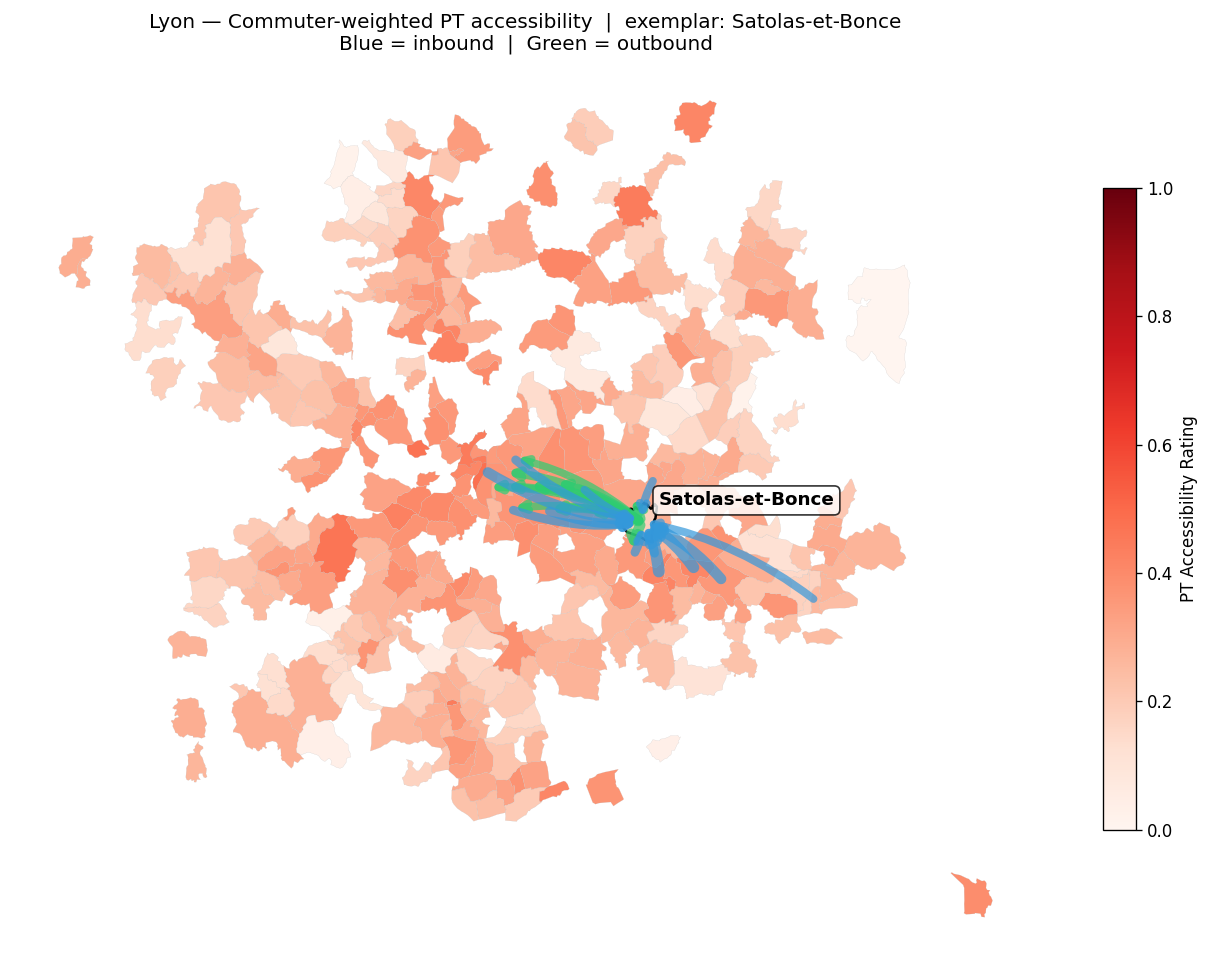

In [ ]:
EXEMPLAR_CODE = candidates.iloc[0]["code"] if len(candidates) else "38507"   # Tignieu-Jameyzieu fallback
ex = lyon_communes[lyon_communes["code"] == EXEMPLAR_CODE].iloc[0]
rating = ex.get("pt_accessibility", None)
if rating is not None and not pd.isna(rating):
    print(f"Exemplar: {ex['nom']} ({ex['code']})  —  PT accessibility rating = {rating:.3f}")
else:
    print(f"Exemplar: {ex['nom']} ({ex['code']})")

fig, ax = plt.subplots(figsize=(11, 11))
lc_plot = lyon_communes.to_crs("EPSG:2154").copy()
col = "pt_accessibility" if "pt_accessibility" in lc_plot.columns else "car_share"
vmin, vmax = (0.0, 1.0) if col == "pt_accessibility" else (0.5, 1.0)
lc_plot.plot(column=col, cmap="Reds", vmin=vmin, vmax=vmax, linewidth=0.1, edgecolor="#bbb",
             ax=ax, legend=True, legend_kwds={"label": "PT Accessibility Rating" if col=="pt_accessibility" else "Car share", "shrink": 0.5})

code_geom = {r["code"]: r.geometry.centroid for _, r in lc_plot.iterrows()}
ex_pt = code_geom.get(EXEMPLAR_CODE)

def draw_arrows(df, partner_col, color):
    for _, fr in df.iterrows():
        other = code_geom.get(fr[partner_col])
        if other is None or ex_pt is None: continue
        lw = 0.6 + 1.2 * np.log1p(fr["total"])
        start, end = (other.x, other.y), (ex_pt.x, ex_pt.y)
        if partner_col == "dest": start, end = end, start
        ax.annotate("", xy=end, xytext=start,
                    arrowprops=dict(arrowstyle="->", color=color, lw=lw, alpha=0.7, connectionstyle="arc3,rad=0.12"))

TOP_N = 12
outs = od_mode[od_mode["origin"] == EXEMPLAR_CODE].nlargest(TOP_N, "total")
ins  = od_mode[od_mode["dest"]   == EXEMPLAR_CODE].nlargest(TOP_N, "total")
draw_arrows(outs, "dest",   "#2ecc71")
draw_arrows(ins,  "origin", "#3498db")

lc_plot[lc_plot["code"] == EXEMPLAR_CODE].boundary.plot(ax=ax, color="#000", linewidth=1.5)
ax.annotate(ex["nom"], xy=(ex_pt.x, ex_pt.y), fontweight="bold", fontsize=11,
            xytext=(10, 10), textcoords="offset points",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))
ax.set_title(f"Lyon — Commuter-weighted PT accessibility  |  exemplar: {ex['nom']}\nBlue = inbound  |  Green = outbound", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 8. HEART slide-22 analog — commute distance + mode shares

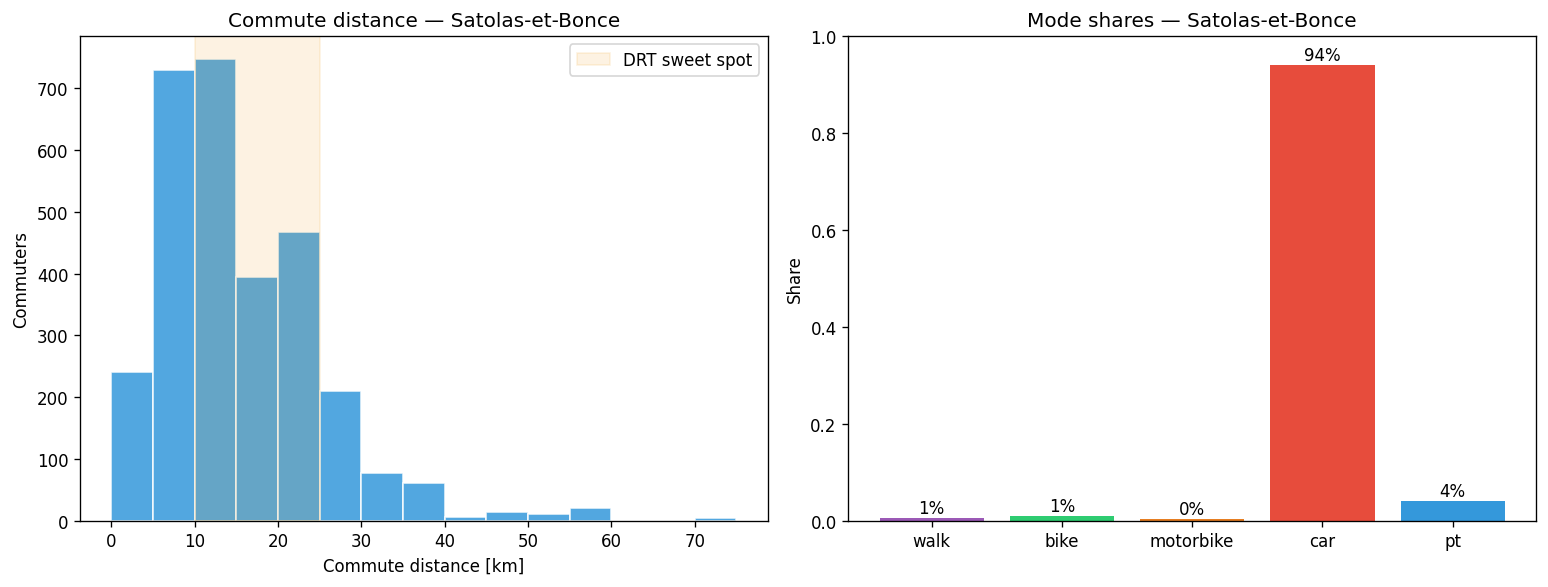

In [ ]:
def add_dist(rows):
    df = rows.merge(lyon_communes[["code","lon","lat"]].rename(columns={"code":"origin","lon":"olon","lat":"olat"}), on="origin", how="left")
    df = df.merge(lyon_communes[["code","lon","lat"]].rename(columns={"code":"dest","lon":"dlon","lat":"dlat"}), on="dest", how="left")
    df["dist_km"] = df.apply(lambda r: hkm(r["olon"], r["olat"], r["dlon"], r["dlat"]) if pd.notna(r["olon"]) else np.nan, axis=1)
    return df

ex_flows = add_dist(od_mode[(od_mode["origin"] == EXEMPLAR_CODE) | (od_mode["dest"] == EXEMPLAR_CODE)])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
bins = np.arange(0, 80, 5)
axL.hist(ex_flows["dist_km"], bins=bins, weights=ex_flows["total"], color="#3498db", edgecolor="white", alpha=0.85)
axL.axvspan(10, 25, color="#f39c12", alpha=0.12, label="DRT sweet spot")
axL.set_xlabel("Commute distance [km]"); axL.set_ylabel("Commuters")
axL.set_title(f"Commute distance — {ex['nom']}"); axL.legend()

mode_totals = pd.Series({
    "walk":       ex_flows["m2"].sum() if "m2" in ex_flows else 0,
    "bike":       ex_flows["m3"].sum() if "m3" in ex_flows else 0,
    "motorbike":  ex_flows["m4"].sum() if "m4" in ex_flows else 0,
    "car":        ex_flows["m5"].sum() if "m5" in ex_flows else 0,
    "pt":         ex_flows["m6"].sum() if "m6" in ex_flows else 0,
})
shares = mode_totals / mode_totals.sum()
axR.bar(shares.index, shares.values, color=["#9b59b6","#2ecc71","#e67e22","#e74c3c","#3498db"])
axR.set_ylabel("Share"); axR.set_title(f"Mode shares — {ex['nom']}"); axR.set_ylim(0, 1)
for i, v in enumerate(shares.values): axR.text(i, v + 0.01, f"{v:.0%}", ha="center")
plt.tight_layout(); plt.show()

## 9. Ranked candidates

Communes meeting all criteria, ordered by PT accessibility rating (worst PT first). Commute volume shown alongside.

In [ ]:
sort_col = "pt_accessibility" if "pt_accessibility" in lyon_communes.columns else "total_flow"
ranking = lyon_communes[mask][show].sort_values(sort_col, ascending=True)
ranking.head(20)

,code,nom,dist_to_lyon_km,dist_to_rail_km,daytime_trips_per_hour,pt_accessibility,connectivity,total_flow,car_share,io_ratio,lyon_share
819,38475,Satolas-et-Bonce,22.436018,5.349996,0.166667,0.182140,0.019157,2983.587873,0.944196,0.563870,0.171296
513,38138,Crémieu,31.047792,14.092802,0.000000,0.283297,0.062176,2555.691993,0.958206,1.045281,0.111112
669,38316,Pont-de-Chéruy,24.356157,8.362286,0.000000,0.309251,0.050420,3761.452505,0.897021,1.297992,0.142661
845,38507,Tignieu-Jameyzieu,25.401451,8.645511,0.000000,0.310612,0.072650,4524.606837,0.952313,1.909662,0.137056


## 10. Expanded PT accessibility — all communes within 60 km of Lyon

The original TTM in §4 was scoped to the pre-filter candidate + their top-15 flow partners + Lyon arrondissements (~358 endpoints). For the interactive map we want PT accessibility computed for every commune close enough to plausibly be a DRT candidate. We rebuild the TTM on endpoints = { `dist_to_lyon_km` ≤ 60 } ∪ { Lyon arrondissements }.

Cached to `cache/ttm_expanded.parquet` (separate file — the original `ttm.parquet` is preserved so §6 and §9 still reflect the paper-baseline pre-filter).

In [ ]:
import sys
sys.path.insert(0, str(HERE))  # make drt_map importable without editable install
import drt_map

CACHE_TTM_EXP = CACHE / "ttm_expanded.parquet"
LYON_ARR = {f"6938{i}" for i in range(1, 10)} | {"69266", "69123"}  # arrondissements + core Lyon + Villeurbanne

expanded_codes = drt_map.compute_expanded_endpoints(
    lyon_communes, radius_km=60.0, lyon_arrondissements=LYON_ARR,
)
print(f"expanded endpoint set: {len(expanded_codes):,} communes")

if CACHE_TTM_EXP.exists():
    ttm_exp = pd.read_parquet(CACHE_TTM_EXP)
    print(f"loaded cached expanded TTM: {len(ttm_exp):,} rows")
elif not OSM_PATH.exists() or not GTFS_DIR.exists():
    ttm_exp = None
    print("OSM or GTFS missing — cannot build expanded TTM.")
else:
    import r5py
    print(f"Building r5py TransportNetwork from {len(clean_feeds)} feeds + OSM …")
    network_exp = r5py.TransportNetwork(str(OSM_PATH), clean_feeds)

    lc_wgs = lyon_communes.to_crs("EPSG:4326").copy()
    lc_wgs["centroid"] = lc_wgs.geometry.centroid
    nodes = gpd.GeoDataFrame({"id": lc_wgs["code"]}, geometry=lc_wgs["centroid"], crs="EPSG:4326")
    nodes = nodes[nodes["id"].isin(expanded_codes)].reset_index(drop=True)
    print(f"routing {len(nodes)} endpoints (expect {len(nodes)**2:,} OD pairs per mode)")

    ttm_car_exp = r5py.TravelTimeMatrix(
        network_exp, origins=nodes, destinations=nodes,
        transport_modes=[r5py.TransportMode.CAR],
        departure=PEAK_START,
    ).rename(columns={"travel_time": "car_min"})
    print(f"  car: {len(ttm_car_exp):,} rows")

    ttm_pt_exp = r5py.TravelTimeMatrix(
        network_exp, origins=nodes, destinations=nodes,
        transport_modes=[r5py.TransportMode.TRANSIT, r5py.TransportMode.WALK],
        departure=PEAK_START,
        departure_time_window=PEAK_WINDOW,
        percentiles=PT_PERCENTILES,
        max_time=dt.timedelta(minutes=180),
    )
    pt_col = [c for c in ttm_pt_exp.columns if c.startswith("travel_time")][0]
    ttm_pt_exp = ttm_pt_exp.rename(columns={pt_col: "pt_min_nowait"})
    print(f"  pt:  {len(ttm_pt_exp):,} rows")

    ttm_exp = ttm_car_exp.merge(
        ttm_pt_exp[["from_id", "to_id", "pt_min_nowait"]],
        on=["from_id", "to_id"], how="outer",
    ).rename(columns={"from_id": "origin", "to_id": "dest"})
    ttm_exp.to_parquet(CACHE_TTM_EXP)
    print(f"wrote {CACHE_TTM_EXP} — {len(ttm_exp):,} rows")

expanded endpoint set: 851 communes
loaded cached expanded TTM: 724,201 rows


### 10b. Recompute PT accessibility + connectivity on the expanded endpoint set

Same formulas as §5 / §5b, applied against `ttm_exp`. Stored as new columns `pt_accessibility_expanded` and `connectivity_expanded` so the §6 / §9 tables keep their original values.

In [ ]:
if ttm_exp is not None:
    merged = od_mode.merge(
        ttm_exp[["origin", "dest", "car_min", "pt_min_nowait"]],
        on=["origin", "dest"], how="left",
    )
    merged["pt_min_nowait"] = merged["pt_min_nowait"].fillna(np.inf)
    merged = merged.dropna(subset=["car_min"])
    merged["score"] = np.minimum(1.0, merged["car_min"] / merged["pt_min_nowait"]).fillna(0.0)
    merged["flow_x_score"] = merged["total"] * merged["score"]

    o_side = merged.groupby("origin", as_index=False).agg(wx=("flow_x_score", "sum"), w=("total", "sum")).rename(columns={"origin": "code"})
    d_side = merged.groupby("dest",   as_index=False).agg(wx=("flow_x_score", "sum"), w=("total", "sum")).rename(columns={"dest":   "code"})
    both = pd.concat([o_side, d_side]).groupby("code", as_index=False).sum()
    both["pt_accessibility_expanded"] = both["wx"] / both["w"].replace(0, np.nan)

    tt = ttm_exp.copy()
    tt["pt_ok"]  = tt["pt_min_nowait"].fillna(np.inf) <= 60
    tt["car_ok"] = tt["car_min"].fillna(np.inf) <= 60
    per_o = tt.groupby("origin", as_index=False).agg(n_pt=("pt_ok", "sum"), n_car=("car_ok", "sum"))
    per_o["connectivity_expanded"] = per_o["n_pt"] / per_o["n_car"].replace(0, np.nan)
    per_o = per_o.rename(columns={"origin": "code"})

    # Drop any prior attempts, then merge fresh
    lyon_communes = lyon_communes.drop(
        columns=[c for c in ("pt_accessibility_expanded", "connectivity_expanded")
                 if c in lyon_communes.columns],
        errors="ignore",
    )
    lyon_communes = lyon_communes.merge(both[["code", "pt_accessibility_expanded"]], on="code", how="left")
    lyon_communes = lyon_communes.merge(per_o[["code", "connectivity_expanded"]], on="code", how="left")

    n_scored = lyon_communes["pt_accessibility_expanded"].notna().sum()
    n_total = len(lyon_communes)
    print(f"communes with expanded PT score: {n_scored:,} / {n_total:,}")
    print("\nworst 10 (best DRT targets):")
    print(lyon_communes.dropna(subset=["pt_accessibility_expanded"])
          .sort_values("pt_accessibility_expanded")
          [["code", "nom", "pt_accessibility_expanded", "connectivity_expanded", "total_flow"]]
          .head(10).to_string(index=False))
    print("\nbest 10 (strongest PT):")
    print(lyon_communes.dropna(subset=["pt_accessibility_expanded"])
          .sort_values("pt_accessibility_expanded", ascending=False)
          [["code", "nom", "pt_accessibility_expanded", "connectivity_expanded", "total_flow"]]
          .head(10).to_string(index=False))
else:
    print("ttm_exp missing — skipping recompute.")

communes with expanded PT score: 850 / 1,498

worst 10 (best DRT targets):
 code                         nom  pt_accessibility_expanded  connectivity_expanded  total_flow
01066                La Burbanche                        0.0               0.010989   36.375000
01277        Nivollet-Montgriffon                        0.0               0.009091   39.666667
69016                    Azolette                        0.0               0.007634   26.521739
01329                   Rossillon                        0.0               0.040000   71.710058
01358 Saint-Germain-les-Paroisses                        0.0               0.010417  128.926959
01110                    Colomieu                        0.0               0.011905   71.750000
01117                     Conzieu                        0.0               0.010526   41.625000
01111                      Conand                        0.0               0.008475   62.769231
01100          Cheignieu-la-Balme                        0.0 

### 10c. DRT opportunity — absolute commuter-km of PT deficit

`pt_accessibility_expanded` is a *normalised average*: Lyon (flow 38k, PT score 0.48) and a 100-commuter rural village (flow 100, PT score 0.0) both appear on the same 0–1 scale — the map can't tell which is the better DRT target.

**DRT opportunity** fixes this by summing the *unmet* commuter-kilometres at each commune:

$$\text{drt\_opportunity}(c) = \sum_{(o,d) : c \in \{o,d\}} \text{flow}(o,d) \cdot (1 - s(o,d)) \cdot \text{dist}(o,d)$$

where $s(o,d) = \min(1, t_\text{car}/t_\text{pt,nowait})$ (same as §5) and $\text{dist}$ is the beeline commute distance in km. Units: commuter-km with deficient PT service. A higher number means more people spending more kilometres in commutes that PT currently serves badly — and the value doesn't dilute with normalisation.

In [ ]:
if ttm_exp is not None:
    od_dist = od_mode.copy()
    if "dist_km" not in od_dist.columns:
        od_dist = od_dist.merge(
            lyon_communes[["code", "lon", "lat"]].rename(columns={"code": "origin", "lon": "olon", "lat": "olat"}),
            on="origin", how="left",
        ).merge(
            lyon_communes[["code", "lon", "lat"]].rename(columns={"code": "dest", "lon": "dlon", "lat": "dlat"}),
            on="dest", how="left",
        )
        od_dist["dist_km"] = od_dist.apply(
            lambda r: hkm(r["olon"], r["olat"], r["dlon"], r["dlat"]) if pd.notna(r["olon"]) else np.nan,
            axis=1,
        )

    deficit = od_dist.merge(
        ttm_exp[["origin", "dest", "car_min", "pt_min_nowait"]],
        on=["origin", "dest"], how="left",
    )
    deficit["pt_min_nowait"] = deficit["pt_min_nowait"].fillna(np.inf)
    deficit = deficit.dropna(subset=["car_min", "dist_km"])
    deficit["access"]   = np.minimum(1.0, deficit["car_min"] / deficit["pt_min_nowait"]).fillna(0.0)
    deficit["deficit"] = 1.0 - deficit["access"]
    deficit["deficit_km"] = deficit["total"] * deficit["deficit"] * deficit["dist_km"]

    # Sum both as origin and destination (consistent with §5's two-sided attribution)
    o_side = deficit.groupby("origin", as_index=False)["deficit_km"].sum().rename(columns={"origin": "code"})
    d_side = deficit.groupby("dest",   as_index=False)["deficit_km"].sum().rename(columns={"dest":   "code"})
    drt_opp = pd.concat([o_side, d_side]).groupby("code", as_index=False)["deficit_km"].sum().rename(columns={"deficit_km": "drt_opportunity_km"})

    lyon_communes = lyon_communes.drop(columns=["drt_opportunity_km"], errors="ignore")
    lyon_communes = lyon_communes.merge(drt_opp, on="code", how="left")

    n_ranked = lyon_communes["drt_opportunity_km"].notna().sum()
    total_deficit_km = lyon_communes["drt_opportunity_km"].sum()
    print(f"communes with DRT opportunity score: {n_ranked:,}")
    print(f"regional total PT-deficit: {total_deficit_km:,.0f} commuter-km/day\n")

    show_cols = ["code", "nom", "drt_opportunity_km", "pt_accessibility_expanded", "total_flow", "dist_to_lyon_km"]
    top = lyon_communes.dropna(subset=["drt_opportunity_km"]).sort_values("drt_opportunity_km", ascending=False)
    print("top 20 DRT opportunity (highest unmet demand, in commuter-km):")
    print(top[show_cols].head(20).to_string(index=False))
else:
    print("ttm_exp missing — skipping DRT opportunity.")

communes with DRT opportunity score: 850
regional total PT-deficit: 16,672,320 commuter-km/day

top 20 DRT opportunity (highest unmet demand, in commuter-km):
 code                     nom  drt_opportunity_km  pt_accessibility_expanded    total_flow  dist_to_lyon_km
69123                    Lyon       739843.295996                   0.390598 232204.820434         1.871180
42218           Saint-Étienne       537719.494769                   0.273225  57195.040924        52.400485
69266            Villeurbanne       519005.325957                   0.357373  89534.567772         2.598265
69383  Lyon 3e Arrondissement       502269.560344                   0.367571  86773.888049         1.146096
69290            Saint-Priest       389322.682181                   0.382094  45767.761754         9.569475
69387  Lyon 7e Arrondissement       349309.744115                   0.377655  60521.288377         3.470992
69259              Vénissieux       252393.068518                   0.362797  37847.2

## 11. Interactive DRT-suitability map

Clickable folium map. Choropleth shows `pt_accessibility_expanded` on an inverted scale (dark = low rating = DRT target). Hover shows the commune name + value. Click opens a popup with the full commute fingerprint (stats table, distance histogram, mode shares, top partners) and draws in/out flow arrows on the map.

Output: `output/drt_suitability_map.html`.

In [ ]:
import importlib
importlib.reload(drt_map) 

<module 'drt_map' from '/mnt/Shared/Code/projects/Dissertation/matsim_scenarios/eqasim-france/scenario-selection/drt_map.py'>

In [ ]:
from IPython.display import IFrame

# Add commute distance to od_mode if not already present (needed for popup histograms)
if "dist_km" not in od_mode.columns:
    _od = od_mode.merge(
        lyon_communes[["code", "lon", "lat"]].rename(columns={"code": "origin", "lon": "olon", "lat": "olat"}),
        on="origin", how="left",
    ).merge(
        lyon_communes[["code", "lon", "lat"]].rename(columns={"code": "dest", "lon": "dlon", "lat": "dlat"}),
        on="dest", how="left",
    )
    _od["dist_km"] = _od.apply(
        lambda r: hkm(r["olon"], r["olat"], r["dlon"], r["dlat"]) if pd.notna(r["olon"]) else np.nan,
        axis=1,
    )
    od_mode = _od

OUT_HTML = HERE / "output" / "drt_suitability_map.html"
shortlist_codes = set(candidates["code"].astype(str)) if len(candidates) else set()

# Fallback: if §10 didn't run, use §5's pt_accessibility + §5b's connectivity
if "pt_accessibility_expanded" not in lyon_communes.columns:
    print("WARNING: pt_accessibility_expanded missing — using §5 pt_accessibility as fallback")
    lyon_communes["pt_accessibility_expanded"] = lyon_communes.get("pt_accessibility")
if "connectivity_expanded" not in lyon_communes.columns:
    lyon_communes["connectivity_expanded"] = lyon_communes.get("connectivity")

m = drt_map.build_map(
    lyon_communes, od_mode,
    rail_gdf=rail_gdf,
    shortlist_codes=shortlist_codes,
    output_path=OUT_HTML,
)
print(f"wrote {OUT_HTML}  ({OUT_HTML.stat().st_size / 1024:.0f} KB)")
IFrame(str(OUT_HTML), width="100%", height=650)

wrote /mnt/Shared/Code/projects/Dissertation/matsim_scenarios/eqasim-france/scenario-selection/output/drt_suitability_map.html  (16987 KB)


## 12. Pareto ranking — commute flow × PT accessibility

Two-axis non-dominated sort over communes in the half-hour drive band.

- **X: `total_flow`** — inbound + outbound commuters per commune (§2)
- **Y: `pt_accessibility_expanded`** — commuter-weighted min(1, car/pt) from §10b (lower = worse PT = better DRT target)

**Scope filter.** `dist_to_lyon_km ∈ [20, 30]` — excludes Lyon métropole belt; approximate half-hour drive band.

**Pareto front 1** = communes where no other in-scope commune has *both* ≥ flow AND ≤ PT access. Peel, repeat for fronts 2, 3, …

Expected use: front-1 communes with high flow are candidate scenario cores. Multiple front-1 communes clustering on the map → candidate area for Paper 1 (rural DRT). Their commute flows into Lyon → Paper 2 (stop-based connector).


In [ ]:
MIN_DIST_KM = 20.0   # exclude Lyon metro belt
MAX_DIST_KM = 30.0   # ~half-hour drive
MIN_FLOW    = 500    # drop tiny communes (avoid degenerate front-1 entries)


def pareto_fronts(values_x, values_y, x_better="higher", y_better="lower"):
    """Non-dominated sorting. Returns front number per row (1 = best)."""
    x = np.asarray(values_x, dtype=float).copy()
    y = np.asarray(values_y, dtype=float).copy()
    if x_better == "lower":
        x = -x
    if y_better == "lower":
        y = -y
    n = len(x)
    front = np.zeros(n, dtype=int)
    remaining = np.ones(n, dtype=bool)
    k = 1
    while remaining.any():
        idx = np.where(remaining)[0]
        xi, yi = x[idx], y[idx]
        dominated = np.zeros(len(idx), dtype=bool)
        for a in range(len(idx)):
            strict = (xi > xi[a]) | (yi > yi[a])
            if ((xi >= xi[a]) & (yi >= yi[a]) & strict).any():
                dominated[a] = True
        front[idx[~dominated]] = k
        remaining[idx[~dominated]] = False
        k += 1
    return front


acc_col = (
    "pt_accessibility_expanded"
    if "pt_accessibility_expanded" in lyon_communes.columns
    else "pt_accessibility"
)
print(f"using accessibility column: {acc_col}")

scope_mask = (
    lyon_communes["dist_to_lyon_km"].between(MIN_DIST_KM, MAX_DIST_KM)
    & (lyon_communes["total_flow"] >= MIN_FLOW)
    & lyon_communes[acc_col].notna()
)
scope = lyon_communes.loc[scope_mask].copy()
print(f"scope: {len(scope):,} communes in {MIN_DIST_KM:.0f}-{MAX_DIST_KM:.0f} km band, flow ≥ {MIN_FLOW:,.0f}")

scope["pareto_front"] = pareto_fronts(
    scope["total_flow"].values,
    scope[acc_col].values,
    x_better="higher", y_better="lower",
)
scope = scope.sort_values(["pareto_front", "total_flow"], ascending=[True, False])

lyon_communes = lyon_communes.drop(columns=["pareto_front"], errors="ignore")
lyon_communes = lyon_communes.merge(
    scope[["code", "pareto_front"]], on="code", how="left",
)

rank_cols = ["code", "nom", "pareto_front", "total_flow", acc_col,
             "dist_to_lyon_km", "car_share", "lyon_share", "io_ratio"]
if "drt_opportunity" in scope.columns:
    rank_cols.insert(5, "drt_opportunity")
if "connectivity_expanded" in scope.columns:
    rank_cols.append("connectivity_expanded")

ranking = scope[rank_cols].reset_index(drop=True)
OUT_CSV = HERE / "output" / "commune_pareto_ranking.csv"
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
ranking.to_csv(OUT_CSV, index=False)
print(f"saved {OUT_CSV}")
print(f"\nFront 1 ({(scope['pareto_front']==1).sum()} communes):")
ranking[ranking["pareto_front"] == 1]


using accessibility column: pt_accessibility_expanded
scope: 88 communes in 20-30 km band, flow ≥ 500
saved /mnt/Shared/Code/projects/Dissertation/matsim_scenarios/eqasim-france/scenario-selection/output/commune_pareto_ranking.csv

Front 1 (7 communes):


,code,nom,pareto_front,total_flow,pt_accessibility_expanded,dist_to_lyon_km,car_share,lyon_share,io_ratio,connectivity_expanded
0,69264,Villefranche-sur-Saône,1,20858.072983,0.349105,27.072323,0.851543,0.251892,0.590179,0.059642
1,38449,Saint-Quentin-Fallavier,1,14442.539172,0.342158,23.575203,0.918694,0.208723,0.125178,0.036496
2,38087,Chasse-sur-Rhône,1,5369.956337,0.278161,20.427399,0.901869,0.212162,0.748117,0.014799
3,38475,Satolas-et-Bonce,1,2983.587873,0.172397,22.436018,0.944196,0.171296,0.563870,0.010163
4,01224,Loyettes,1,1918.054390,0.138986,28.046558,0.967008,0.131111,2.807293,0.002611
5,01378,Saint-Maurice-de-Gourdans,1,1358.378535,0.085726,25.014340,0.958117,0.179499,10.701561,0.002398
6,01361,Saint-Jean-de-Niost,1,814.913032,0.047151,28.756884,0.934766,0.203855,26.671314,0.002315


### 12a. Pareto scatter

Each in-scope commune as a dot. Front-1 (red) = non-dominated. §9 shortlist circled for cross-check.


saved /mnt/Shared/Code/projects/Dissertation/matsim_scenarios/eqasim-france/scenario-selection/output/pareto_scatter.png


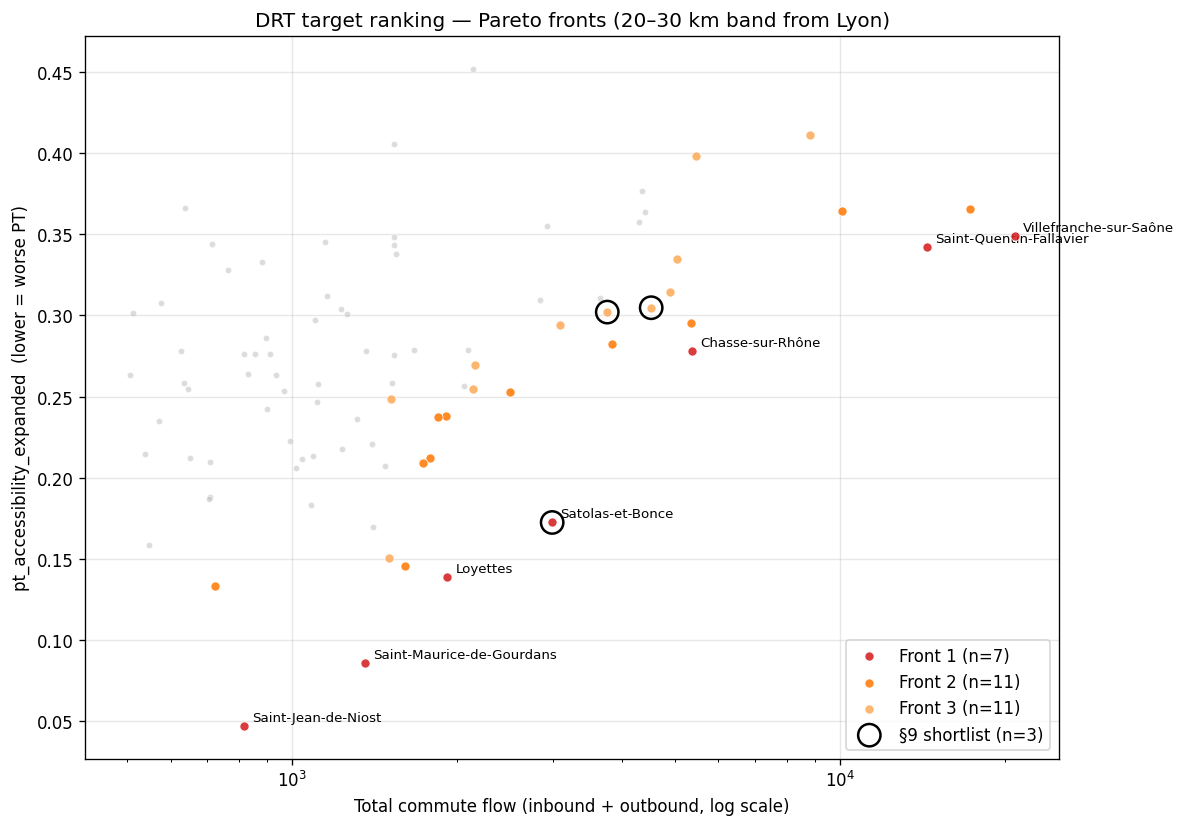

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

front_palette = {1: "#d62728", 2: "#ff7f0e", 3: "#fdae61"}
for f in sorted(scope["pareto_front"].unique()):
    sub = scope[scope["pareto_front"] == f]
    c = front_palette.get(f, "#bbbbbb")
    label = f"Front {int(f)} (n={len(sub)})" if f <= 3 else None
    ax.scatter(
        sub["total_flow"], sub[acc_col],
        s=30 if f <= 3 else 14,
        c=c, edgecolor="white", linewidth=0.5,
        alpha=0.9 if f <= 3 else 0.5,
        label=label, zorder=10 - int(f),
    )

# §9 shortlist overlay (if computed earlier in notebook)
try:
    shortlist_codes_v = set(candidates["code"].astype(str))
    short = scope[scope["code"].astype(str).isin(shortlist_codes_v)]
    if len(short):
        ax.scatter(
            short["total_flow"], short[acc_col],
            s=180, facecolor="none", edgecolor="black",
            linewidth=1.5, label=f"§9 shortlist (n={len(short)})", zorder=20,
        )
except NameError:
    pass

# Label front-1
for _, r in scope[scope["pareto_front"] == 1].iterrows():
    ax.annotate(
        r["nom"], (r["total_flow"], r[acc_col]),
        xytext=(5, 3), textcoords="offset points", fontsize=8,
    )

ax.set_xscale("log")
ax.set_xlabel("Total commute flow (inbound + outbound, log scale)")
ax.set_ylabel(f"{acc_col}  (lower = worse PT)")
ax.set_title(
    f"DRT target ranking — Pareto fronts "
    f"({MIN_DIST_KM:.0f}–{MAX_DIST_KM:.0f} km band from Lyon)"
)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", frameon=True)

fig.tight_layout()
out = HERE / "output" / "pareto_scatter.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"saved {out}")
plt.show()


### 12b. Pareto map

Front colour on commune polygons. Dashed rings = 20 km / 30 km from Lyon Part-Dieu. Clusters of front-1 (red) communes identify candidate scenario areas.


/tmp/ipykernel_541431/3600160526.py:43: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper left", frameon=True)


saved /mnt/Shared/Code/projects/Dissertation/matsim_scenarios/eqasim-france/scenario-selection/output/pareto_map.png


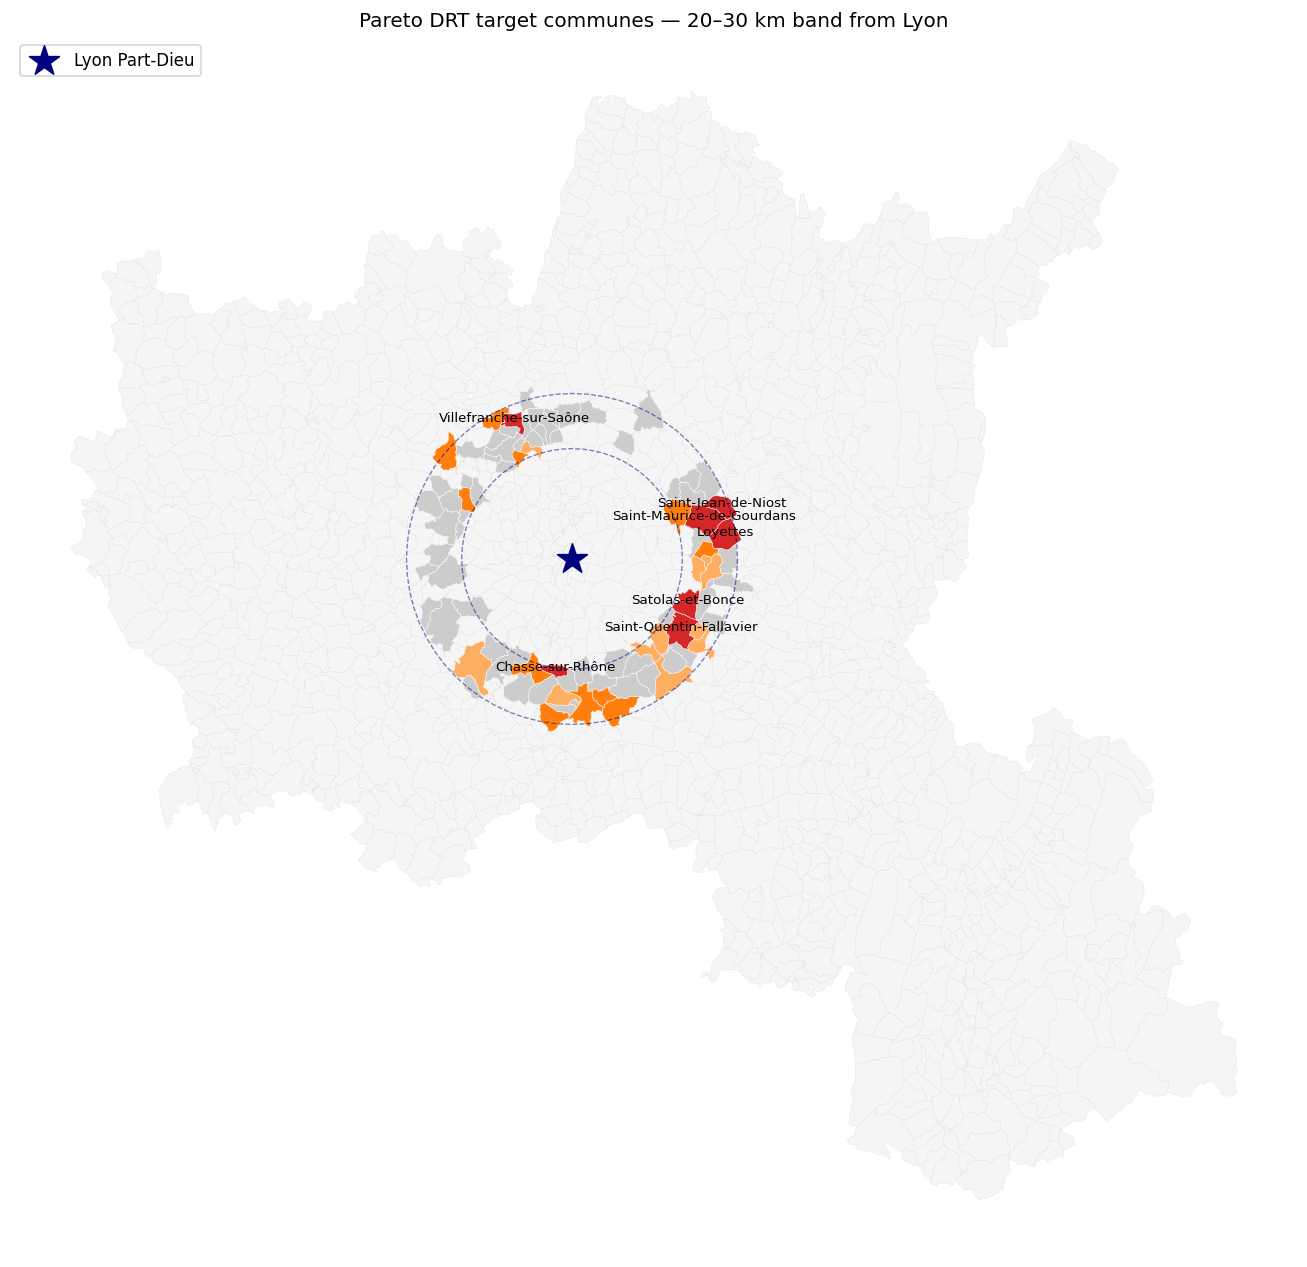

In [ ]:
from shapely.geometry import Point

fig, ax = plt.subplots(figsize=(11, 11))
lc_plot = lyon_communes.to_crs("EPSG:2154").copy()

# background: all Lyon-départements communes
lc_plot.plot(ax=ax, color="#f5f5f5", edgecolor="#dddddd", linewidth=0.2)

front_palette_map = {1.0: "#d62728", 2.0: "#ff7f0e", 3.0: "#fdae61"}

# dominated scope (in distance band but not on front 1-3)
dominated = lc_plot[
    lc_plot["pareto_front"].notna()
    & ~lc_plot["pareto_front"].isin(front_palette_map)
]
if len(dominated):
    dominated.plot(ax=ax, color="#cccccc", edgecolor="white", linewidth=0.3, label="Dominated (in scope)")

# front layers
for f, c in front_palette_map.items():
    sub = lc_plot[lc_plot["pareto_front"] == f]
    if len(sub):
        sub.plot(ax=ax, color=c, edgecolor="white", linewidth=0.3, label=f"Front {int(f)}")

# front-1 labels
for _, r in lc_plot[lc_plot["pareto_front"] == 1.0].iterrows():
    ax.annotate(
        r["nom"], (r.geometry.centroid.x, r.geometry.centroid.y),
        fontsize=8, ha="center", color="black",
    )

# Lyon marker + distance rings
lyon_pt = gpd.GeoSeries(
    [Point(LYON_CENTRE_LON, LYON_CENTRE_LAT)], crs="EPSG:4326",
).to_crs("EPSG:2154").iloc[0]
ax.scatter(lyon_pt.x, lyon_pt.y, marker="*", s=350, c="navy", zorder=10, label="Lyon Part-Dieu")
for r_km in (MIN_DIST_KM, MAX_DIST_KM):
    ring = lyon_pt.buffer(r_km * 1000).boundary
    ax.plot(*ring.xy, linestyle="--", color="navy", linewidth=0.8, alpha=0.5)

ax.set_axis_off()
ax.set_title(f"Pareto DRT target communes — {MIN_DIST_KM:.0f}–{MAX_DIST_KM:.0f} km band from Lyon")
ax.legend(loc="upper left", frameon=True)

fig.tight_layout()
out = HERE / "output" / "pareto_map.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"saved {out}")
plt.show()


## 13. Paper 1 Reframe — Local (non-Lyon) Commute Analysis

**Paper 1** asks: *can DRT serve as a PT alternative for intra-regional commuters?*  
**Paper 2** asks: *can DRT connect those same commuters to Lyon?*

The eqasim simulation includes both populations, but Paper 1 should only analyse the **local** (non-Lyon) OD pairs — trips between communes within the study radius where neither endpoint is Lyon.

**Lyon exclusion zone** — communes within 10 km of Lyon Part-Dieu. Any OD pair where either endpoint is in this zone is excluded from Paper 1 metrics. The study circle (service radius) is also constrained to exclude Lyon, so the DRT service only operates locally.

**What this section computes:**
1. `od_local` — filtered OD table (neither endpoint in Lyon zone)
2. `local_total` per commune — local inbound + outbound commuters
3. `local_pt_accessibility` per commune — same §5 formula but on local OD pairs only
4. These feed §14–15 where we size the service radius for two candidate clusters.

In [92]:
# ── Lyon exclusion zone ──────────────────────────────────────────────────
# Communes within LYON_ZONE_KM of Part-Dieu are treated as "Lyon" and
# excluded from Paper 1 OD analysis (Lyon commuters → Paper 2 arc).
LYON_ZONE_KM = 10.0
lyon_zone_codes = set(
    lyon_communes.loc[lyon_communes["dist_to_lyon_km"] <= LYON_ZONE_KM, "code"]
)
print(f"Lyon zone: {len(lyon_zone_codes)} communes within {LYON_ZONE_KM} km of Part-Dieu")

# ── Local OD pairs: neither endpoint in Lyon zone ────────────────────────
od_local = od_mode[
    ~od_mode["origin"].isin(lyon_zone_codes) &
    ~od_mode["dest"].isin(lyon_zone_codes)
].copy()
all_flow   = od_mode["total"].sum()
local_flow = od_local["total"].sum()
print(f"\nAll OD commuters   : {all_flow:,.0f}")
print(f"Local OD commuters : {local_flow:,.0f}  ({local_flow / all_flow:.1%} of total — {(all_flow - local_flow) / all_flow:.1%} are Lyon-bound)")

# ── Per-commune local flow (inbound + outbound, Lyon-excluded) ───────────
loc_out = (od_local.groupby("origin", as_index=False)
           .agg(flow=("total","sum"), car_flow=("car","sum"))
           .rename(columns={"origin":"code"}))
loc_in  = (od_local.groupby("dest", as_index=False)
           .agg(flow=("total","sum"), car_flow=("car","sum"))
           .rename(columns={"dest":"code"}))
loc_agg = (pd.concat([loc_out, loc_in])
           .groupby("code", as_index=False).sum())
loc_agg["local_car_share"] = loc_agg["car_flow"] / loc_agg["flow"].replace(0, np.nan)

# ── Local PT accessibility (same §5 formula, Lyon-free OD pairs) ─────────
if ttm_exp is not None:
    m_loc = od_local.merge(
        ttm_exp[["origin","dest","car_min","pt_min_nowait"]], on=["origin","dest"], how="left"
    )
    m_loc["pt_min_nowait"] = m_loc["pt_min_nowait"].fillna(np.inf)
    m_loc = m_loc.dropna(subset=["car_min"])
    m_loc["score"] = np.minimum(1.0, m_loc["car_min"] / m_loc["pt_min_nowait"]).fillna(0.0)
    m_loc["flow_x_score"] = m_loc["total"] * m_loc["score"]
    o_s = m_loc.groupby("origin",as_index=False).agg(wx=("flow_x_score","sum"),w=("total","sum")).rename(columns={"origin":"code"})
    d_s = m_loc.groupby("dest",  as_index=False).agg(wx=("flow_x_score","sum"),w=("total","sum")).rename(columns={"dest":  "code"})
    both_pt = pd.concat([o_s, d_s]).groupby("code", as_index=False).sum()
    both_pt["local_pt_accessibility"] = both_pt["wx"] / both_pt["w"].replace(0, np.nan)
    loc_agg = loc_agg.merge(both_pt[["code","local_pt_accessibility"]], on="code", how="left")

drop = [c for c in ("local_total","local_car_share","local_pt_accessibility") if c in lyon_communes.columns]
lyon_communes = lyon_communes.drop(columns=drop, errors="ignore")
has_local_pt = "local_pt_accessibility" in loc_agg.columns
merge_cols = ["code","flow","local_car_share"] + (["local_pt_accessibility"] if has_local_pt else [])
lyon_communes = lyon_communes.merge(
    loc_agg[merge_cols].rename(columns={"flow":"local_total"}), on="code", how="left"
)

show_local = [c for c in ["code","nom","local_total","local_pt_accessibility","local_car_share","lyon_share","dist_to_lyon_km"]
              if c in lyon_communes.columns]
print("\nTop 10 by local (non-Lyon) flow:")
print(lyon_communes.dropna(subset=["local_total"])
      .sort_values("local_total", ascending=False)[show_local].head(10).to_string(index=False))

Lyon zone: 40 communes within 10.0 km of Part-Dieu

All OD commuters   : 1,420,934
Local OD commuters : 785,630  (55.3% of total — 44.7% are Lyon-bound)

Top 10 by local (non-Lyon) flow:
 code                    nom  local_total  local_pt_accessibility  local_car_share  lyon_share  dist_to_lyon_km
38185               Grenoble 81443.075951                     NaN         0.584724    0.013923        93.053761
42218          Saint-Étienne 52832.182190                0.247024         0.868564    0.115818        52.400485
01053        Bourg-en-Bresse 24855.245827                0.309172         0.939999    0.078500        57.733069
38421   Saint-Martin-d'Hères 22732.451985                     NaN         0.615077    0.006305        95.996366
38151             Échirolles 22112.590421                     NaN         0.729786    0.006386        95.473313
42187                 Roanne 18699.372950                     NaN         0.925579    0.039795        68.080030
38053       Bourgoin-Jallieu 

## 14. Paper 1 Cluster Definitions — Radius Sweep

Two Pareto-front-1 clusters are candidates for the Paper 1 study area:

| Cluster | Direction | Core INSEE codes | Approx. dist. to Lyon |
|---|---|---|---|
| **NE — Loyettes** | Northeast | 01224, 01378, 01361 | ~27–29 km |
| **SE — SQF** | Southeast | 38449, 38475 | ~22–24 km |

For each cluster we compute the **cluster centroid** (Lambert-93 centroid of the polygon union), then sweep radii 5–35 km. At each radius:
- `n_communes` — communes whose centroid falls within the radius, excluding the Lyon zone
- `local_flow` — MOBPRO OD pairs where **both** origin and destination are in the local zone (neither in the Lyon zone)
- `local_pt_acc` — commuter-weighted car/pt score on those pairs (same formula as §5, but Lyon-free)
- `lyon_included` — True if any Lyon-zone commune centroid falls within the radius

**Maximum Lyon-free radius** = largest radius where `lyon_included` is False — this is the constraint that drives Paper 1's service boundary.

In [93]:
CLUSTERS = {
    "NE — Loyettes": {
        "codes": ["01224", "01378", "01361"],
        "color": "#e74c3c",
        "label": "Loyettes / Ain-Rhône (NE)",
    },
    "SE — SQF": {
        "codes": ["38449", "38475"],
        "color": "#2980b9",
        "label": "Saint-Quentin-Fallavier (SE)",
    },
}

# ── Cluster centroids (project → Lambert-93 union centroid → WGS84) ─────
cluster_info = {}
for name, cfg in CLUSTERS.items():
    subs = lyon_communes[lyon_communes["code"].isin(cfg["codes"])]
    if subs.empty:
        print(f"WARNING: no communes matched for {name}")
        continue
    centroid_lcc = subs.to_crs("EPSG:2154").geometry.union_all().centroid
    c_wgs = gpd.GeoSeries([centroid_lcc], crs="EPSG:2154").to_crs("EPSG:4326").iloc[0]
    clon, clat = c_wgs.x, c_wgs.y
    d_lyon = hkm(LYON_CENTRE_LON, LYON_CENTRE_LAT, clon, clat)
    cluster_info[name] = {**cfg, "clon": clon, "clat": clat, "dist_to_lyon": d_lyon}
    print(f"{name}: ({clat:.4f}°N, {clon:.4f}°E)  |  {d_lyon:.1f} km to Part-Dieu")
    print(f"  core: {', '.join(subs['nom'].tolist())}")

# ── Distances from each cluster centroid to every commune ───────────────
for name, info in cluster_info.items():
    col = f"_d_{name[:2]}"   # short unique column name
    lyon_communes[col] = lyon_communes.apply(
        lambda r: hkm(info["clon"], info["clat"], r["lon"], r["lat"])
        if pd.notna(r.get("lon")) else np.nan,
        axis=1,
    )
    info["dist_col"] = col

# ── Pre-join od_mode with ttm_exp for fast per-radius scoring ───────────
if ttm_exp is not None:
    _tt = od_mode.merge(
        ttm_exp[["origin", "dest", "car_min", "pt_min_nowait"]], on=["origin", "dest"], how="left"
    )
    _tt["score"] = np.where(
        _tt["car_min"].notna(),
        np.minimum(1.0, _tt["car_min"] / _tt["pt_min_nowait"].fillna(np.inf)).fillna(0.0),
        np.nan,
    )
    _tt["flow_x_score"] = _tt["total"] * _tt["score"].fillna(0.0)
    od_scored = _tt[_tt["car_min"].notna()].copy()
    del _tt
else:
    od_scored = None

# ── Sweep ─────────────────────────────────────────────────────────────────
RADII_KM = list(range(5, 36, 1))

def _sweep_radius(dist_col, radius_km, communes_df, od_full, od_sc, lyon_zone):
    in_zone     = set(communes_df.loc[communes_df[dist_col] <= radius_km, "code"])
    lyon_incl   = bool(in_zone & lyon_zone)
    local_zone  = in_zone - lyon_zone
    local_od    = od_full[od_full["origin"].isin(local_zone) & od_full["dest"].isin(local_zone)]
    local_flow  = local_od["total"].sum()
    pt_acc = np.nan
    if od_sc is not None:
        sc = od_sc[od_sc["origin"].isin(local_zone) & od_sc["dest"].isin(local_zone)]
        w  = sc["total"].sum()
        pt_acc = sc["flow_x_score"].sum() / w if w > 0 else np.nan
    return {"radius_km": radius_km, "n_communes": len(local_zone),
            "local_flow": local_flow, "local_pt_acc": pt_acc, "lyon_included": lyon_incl}

sweep = {}
for name, info in cluster_info.items():
    rows = [_sweep_radius(info["dist_col"], r, lyon_communes, od_mode, od_scored, lyon_zone_codes)
            for r in RADII_KM]
    res  = pd.DataFrame(rows)
    mfr  = res.loc[~res["lyon_included"], "radius_km"].max()
    info["max_free_radius"] = mfr
    at   = res[res["radius_km"] == mfr].iloc[0]
    sweep[name] = res
    print(f"\n{name}")
    print(f"  Max Lyon-free radius : {mfr} km")
    print(f"  Communes in zone     : {int(at['n_communes'])}")
    print(f"  Local commuters/day  : {at['local_flow']:,.0f}")
    pt_s = f"{at['local_pt_acc']:.3f}" if pd.notna(at['local_pt_acc']) else "n/a"
    print(f"  Local PT access      : {pt_s}  (lower = more car-dependent)")

NE — Loyettes: (45.8150°N, 5.1965°E)  |  26.9 km to Part-Dieu
  core: Loyettes, Saint-Jean-de-Niost, Saint-Maurice-de-Gourdans
SE — SQF: (45.6576°N, 5.1155°E)  |  23.0 km to Part-Dieu
  core: Saint-Quentin-Fallavier, Satolas-et-Bonce

NE — Loyettes
  Max Lyon-free radius : 18 km
  Communes in zone     : 79
  Local commuters/day  : 29,625
  Local PT access      : 0.220  (lower = more car-dependent)

SE — SQF
  Max Lyon-free radius : 13 km
  Communes in zone     : 38
  Local commuters/day  : 19,604
  Local PT access      : 0.312  (lower = more car-dependent)


## 15. Cluster Comparison — Radius Sweep Visualisation

Three panels: local commuter volume, commune count, and local PT captivity — all as a function of radius from the cluster centroid. Dashed vertical line = maximum Lyon-free radius for that cluster. Grey shading = radii where at least one Lyon-zone commune enters the circle.

Map shows both clusters at their optimal radius (solid circle) and at +2 km (dashed) to illustrate where Lyon starts entering the zone.

saved /mnt/Shared/Code/projects/Dissertation/matsim_scenarios/eqasim-france/scenario-selection/output/paper1_cluster_radius_comparison.png


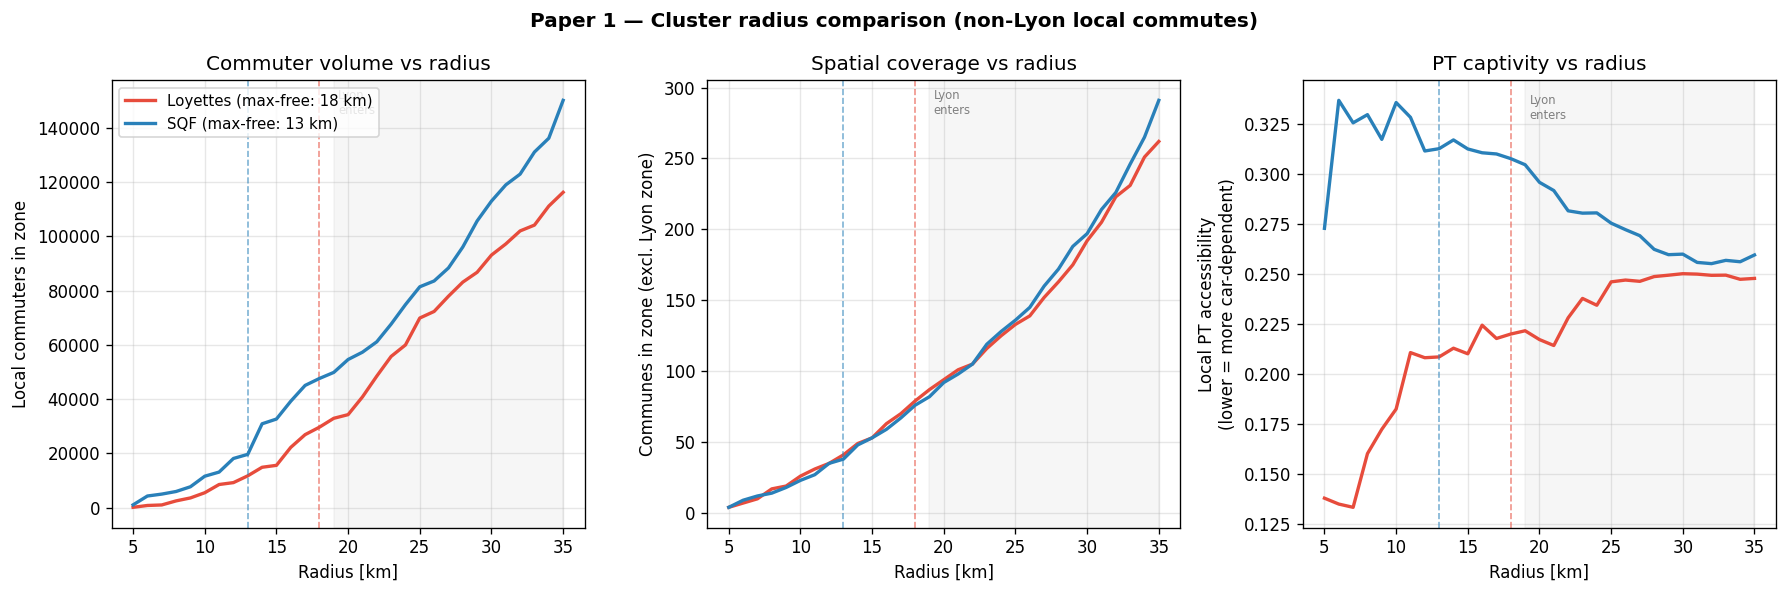

saved /mnt/Shared/Code/projects/Dissertation/matsim_scenarios/eqasim-france/scenario-selection/output/paper1_cluster_map.png


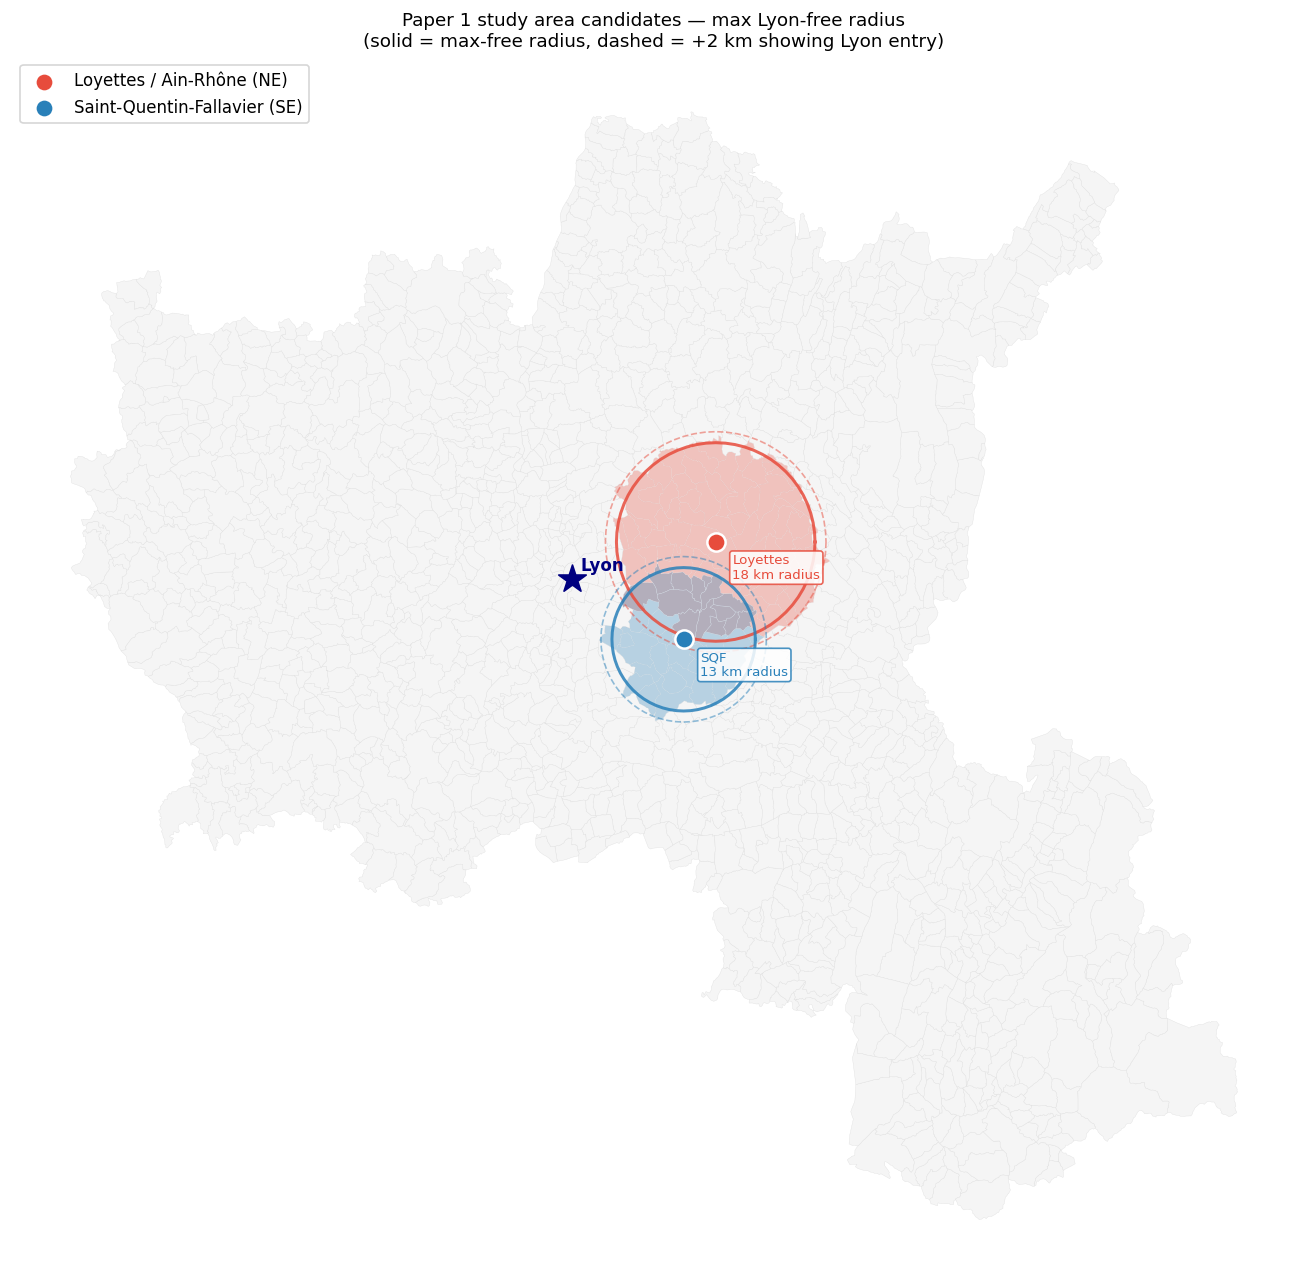


PAPER 1 CLUSTER COMPARISON — at maximum Lyon-free radius

NE — Loyettes  (Loyettes / Ain-Rhône (NE))
  Centroid               : 45.8150°N, 5.1965°E
  Centroid → Lyon        : 26.9 km
  Max Lyon-free radius   : 18 km
  Communes in study area : 79
  Local commuters/day    : 29,625
  Local PT accessibility : 0.220  (lower = more car-dependent)
  Core communes:
    Loyettes                          local=   1482  pt=0.105  lyon_share=13%
    Saint-Jean-de-Niost               local=    494  pt=0.066  lyon_share=20%
    Saint-Maurice-de-Gourdans         local=    899  pt=0.063  lyon_share=18%

SE — SQF  (Saint-Quentin-Fallavier (SE))
  Centroid               : 45.6576°N, 5.1155°E
  Centroid → Lyon        : 23.0 km
  Max Lyon-free radius   : 13 km
  Communes in study area : 38
  Local commuters/day    : 19,604
  Local PT accessibility : 0.312  (lower = more car-dependent)
  Core communes:
    Saint-Quentin-Fallavier           local=  12035  pt=0.321  lyon_share=21%
    Satolas-et-Bonce      

In [94]:
from shapely.geometry import Point as _ShapelyPoint

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
panel_specs = [
    ("local_flow",   "Local commuters in zone",                         "Commuter volume vs radius"),
    ("n_communes",   "Communes in zone (excl. Lyon zone)",               "Spatial coverage vs radius"),
    ("local_pt_acc", "Local PT accessibility\n(lower = more car-dependent)", "PT captivity vs radius"),
]

for name, res in sweep.items():
    info  = cluster_info[name]
    color = info["color"]
    mfr   = info["max_free_radius"]
    label = f"{name.split('—')[1].strip()} (max-free: {mfr:.0f} km)"
    for ax_idx, (col, ylabel, title) in enumerate(panel_specs):
        ax = axes[ax_idx]
        ax.plot(res["radius_km"], res[col], color=color, label=label, linewidth=2)
        ax.axvline(mfr, color=color, linestyle="--", linewidth=1.0, alpha=0.6)
        ax.set_xlabel("Radius [km]")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

# Shade radii where Lyon enters any cluster circle
ref = next(iter(sweep.values()))
first_lyon_r = ref.loc[ref["lyon_included"], "radius_km"].min() if ref["lyon_included"].any() else None
if first_lyon_r:
    for ax in axes:
        ax.axvspan(first_lyon_r, RADII_KM[-1], alpha=0.07, color="grey")
        ax.text(first_lyon_r + 0.3, ax.get_ylim()[1] * 0.98, "Lyon\nenters",
                fontsize=7, color="grey", va="top")
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("Paper 1 — Cluster radius comparison (non-Lyon local commutes)", fontsize=12, fontweight="bold")
fig.tight_layout()
out_sweep = HERE / "output" / "paper1_cluster_radius_comparison.png"
fig.savefig(out_sweep, dpi=150, bbox_inches="tight")
print(f"saved {out_sweep}")
plt.show()

# ── Map: both clusters at their max-free radius ──────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 11))
lc2154 = lyon_communes.to_crs("EPSG:2154")
lc2154.plot(ax=ax2, color="#f5f5f5", edgecolor="#dddddd", linewidth=0.2)

for name, info in cluster_info.items():
    mfr   = info["max_free_radius"]
    in_zone = set(lyon_communes.loc[lyon_communes[info["dist_col"]] <= mfr, "code"])
    local_zone = in_zone - lyon_zone_codes
    lc2154[lc2154["code"].isin(local_zone)].plot(
        ax=ax2, color=info["color"], alpha=0.30, edgecolor="white", linewidth=0.3
    )
    cx2154, cy2154 = (
        gpd.GeoSeries([_ShapelyPoint(info["clon"], info["clat"])], crs="EPSG:4326")
        .to_crs("EPSG:2154").iloc[0].coords[0]
    )
    ax2.scatter(cx2154, cy2154, s=120, c=info["color"], zorder=10, edgecolor="white", linewidth=1.5,
                label=info["label"])
    ring_solid = _ShapelyPoint(cx2154, cy2154).buffer(mfr * 1000).boundary
    ring_dash  = _ShapelyPoint(cx2154, cy2154).buffer((mfr + 2) * 1000).boundary
    ax2.plot(*ring_solid.xy, color=info["color"], linestyle="-",  linewidth=1.8, alpha=0.85)
    ax2.plot(*ring_dash.xy,  color=info["color"], linestyle="--", linewidth=1.0, alpha=0.5)
    ax2.annotate(
        f"{name.split('—')[1].strip()}\n{mfr:.0f} km radius",
        (cx2154, cy2154), xytext=(10, -22), textcoords="offset points", fontsize=8,
        color=info["color"], bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=info["color"], alpha=0.85),
    )

lyon_2154 = gpd.GeoSeries([_ShapelyPoint(LYON_CENTRE_LON, LYON_CENTRE_LAT)], crs="EPSG:4326").to_crs("EPSG:2154").iloc[0]
ax2.scatter(lyon_2154.x, lyon_2154.y, marker="*", s=300, c="navy", zorder=10)
ax2.annotate("Lyon", (lyon_2154.x, lyon_2154.y), xytext=(5, 5), textcoords="offset points",
             fontsize=10, color="navy", fontweight="bold")
ax2.set_axis_off()
ax2.set_title("Paper 1 study area candidates — max Lyon-free radius\n"
              "(solid = max-free radius, dashed = +2 km showing Lyon entry)", fontsize=11)
ax2.legend(loc="upper left")
fig2.tight_layout()
out_map = HERE / "output" / "paper1_cluster_map.png"
fig2.savefig(out_map, dpi=150, bbox_inches="tight")
print(f"saved {out_map}")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("PAPER 1 CLUSTER COMPARISON — at maximum Lyon-free radius")
print("=" * 70)
for name, info in cluster_info.items():
    res = sweep[name]
    mfr = info["max_free_radius"]
    row = res[res["radius_km"] == mfr].iloc[0]
    print(f"\n{name}  ({info['label']})")
    print(f"  Centroid               : {info['clat']:.4f}°N, {info['clon']:.4f}°E")
    print(f"  Centroid → Lyon        : {info['dist_to_lyon']:.1f} km")
    print(f"  Max Lyon-free radius   : {mfr:.0f} km")
    print(f"  Communes in study area : {int(row['n_communes'])}")
    print(f"  Local commuters/day    : {row['local_flow']:,.0f}")
    pt_str = f"{row['local_pt_acc']:.3f}  (lower = more car-dependent)" if pd.notna(row['local_pt_acc']) else "n/a"
    print(f"  Local PT accessibility : {pt_str}")
    core = lyon_communes[lyon_communes["code"].isin(info["codes"])]
    if len(core):
        print("  Core communes:")
        for _, cr in core.iterrows():
            lt  = cr.get("local_total", np.nan)
            lpt = cr.get("local_pt_accessibility", cr.get("pt_accessibility_expanded", np.nan))
            ls  = cr.get("lyon_share", np.nan)
            lt_s  = f"{lt:7.0f}" if pd.notna(lt)  else "    n/a"
            lpt_s = f"{lpt:.3f}"  if pd.notna(lpt) else " n/a "
            ls_s  = f"{ls:.0%}"   if pd.notna(ls)  else "n/a"
            print(f"    {cr['nom']:32s}  local={lt_s}  pt={lpt_s}  lyon_share={ls_s}")

## 16. Fixed Study Radii — Paper 1 vs Paper 2 Commuter Volumes

Applies two chosen radii (Loyettes 20 km, SQF 15 km) and computes:

- **Paper 1** — commutes where *both* origin and destination are inside the local zone (neither in Lyon zone). This is the captive intra-regional DRT demand.
- **Paper 2** — commutes where the *origin* is inside the local zone and the *destination* is in the Lyon zone. These are the Lyon-bound trips Paper 1 misses; Paper 2's arc catches them with a DRT↔rail connector.


NE — Loyettes  |  radius: 20 km
  NOTE: 1 Lyon-zone commune(s) inside circle
  Communes in local zone : 94

  PAPER 1 — intra-zone commutes (both endpoints in zone):
    Commuters/day  :   34,242
    Car share      :   96.0%
    Mode breakdown : walk=1%  bike=1%  motorbike=1%  car=95%  PT=2%
    OD pairs       :    1,790

  PAPER 2 — zone → Lyon commutes:
    Commuters/day  :   38,649
    Car share      :   80.7%
    Mode breakdown : walk=0%  bike=1%  motorbike=1%  car=80%  PT=18%
    OD pairs       :    1,302

  All outbound from zone : 91,717
    P1 local share : 37.3%
    P2 Lyon share  : 42.1%
    Other          : 20.5%  (18,825 — destinations outside zone and outside Lyon)

SE — SQF  |  radius: 15 km
  NOTE: 2 Lyon-zone commune(s) inside circle
  Communes in local zone : 53

  PAPER 1 — intra-zone commutes (both endpoints in zone):
    Commuters/day  :   32,617
    Car share      :   94.0%
    Mode breakdown : walk=1%  bike=1%  motorbike=1%  car=93%  PT=4%
    OD pairs       :   

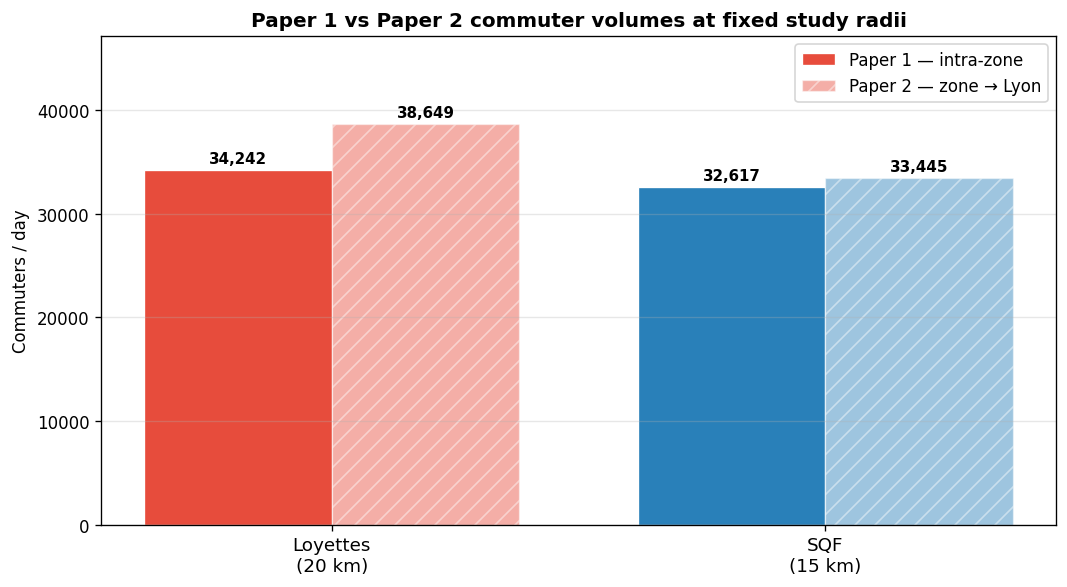

In [95]:
# Fixed radii chosen after §14–15 sweep
STUDY_RADII = {
    "NE — Loyettes": 20,
    "SE — SQF":      15,
}

MODE_LABELS = {"m2": "walk", "m3": "bike", "m4": "motorbike", "m5": "car", "m6": "PT"}

rows_summary = []

for name, r_km in STUDY_RADII.items():
    info         = cluster_info[name]
    in_zone      = set(lyon_communes.loc[lyon_communes[info["dist_col"]] <= r_km, "code"])
    local_zone   = in_zone - lyon_zone_codes
    lyon_overlap = in_zone & lyon_zone_codes

    # Paper 1: both endpoints in local zone (neither in Lyon zone)
    od_p1 = od_mode[od_mode["origin"].isin(local_zone) & od_mode["dest"].isin(local_zone)]

    # Paper 2: origin in local zone → destination in Lyon zone
    od_p2 = od_mode[od_mode["origin"].isin(local_zone) & od_mode["dest"].isin(lyon_zone_codes)]

    # All outbound from local zone (for share calculation)
    od_all_out = od_mode[od_mode["origin"].isin(local_zone)]

    p1_total = od_p1["total"].sum()
    p1_car   = od_p1["car"].sum()
    p2_total = od_p2["total"].sum()
    p2_car   = od_p2["car"].sum()
    all_out  = od_all_out["total"].sum()

    rows_summary.append({
        "cluster": name, "radius_km": r_km,
        "lyon_communes_in_zone": len(lyon_overlap),
        "local_communes": len(local_zone),
        "p1_commuters": p1_total,
        "p1_car_share": p1_car / p1_total if p1_total else np.nan,
        "p2_commuters": p2_total,
        "p2_car_share": p2_car / p2_total if p2_total else np.nan,
        "all_outbound": all_out,
    })

    p1_modes = {lbl: od_p1[col].sum() for col, lbl in MODE_LABELS.items() if col in od_p1.columns}
    p2_modes = {lbl: od_p2[col].sum() for col, lbl in MODE_LABELS.items() if col in od_p2.columns}

    print(f"\n{'='*60}")
    print(f"{name}  |  radius: {r_km} km")
    if lyon_overlap:
        print(f"  NOTE: {len(lyon_overlap)} Lyon-zone commune(s) inside circle")
    print(f"  Communes in local zone : {len(local_zone)}")

    print(f"\n  PAPER 1 — intra-zone commutes (both endpoints in zone):")
    print(f"    Commuters/day  : {p1_total:>8,.0f}")
    if p1_total:
        print(f"    Car share      : {p1_car/p1_total:>7.1%}")
        mode_str = "  ".join(f"{lbl}={v/p1_total:.0%}" for lbl, v in p1_modes.items() if v > 0)
        print(f"    Mode breakdown : {mode_str}")
    print(f"    OD pairs       : {len(od_p1):>8,}")

    print(f"\n  PAPER 2 — zone → Lyon commutes:")
    print(f"    Commuters/day  : {p2_total:>8,.0f}")
    if p2_total:
        print(f"    Car share      : {p2_car/p2_total:>7.1%}")
        mode_str = "  ".join(f"{lbl}={v/p2_total:.0%}" for lbl, v in p2_modes.items() if v > 0)
        print(f"    Mode breakdown : {mode_str}")
    print(f"    OD pairs       : {len(od_p2):>8,}")

    print(f"\n  All outbound from zone : {all_out:,.0f}")
    if all_out:
        other = all_out - p1_total - p2_total
        print(f"    P1 local share : {p1_total/all_out:.1%}")
        print(f"    P2 Lyon share  : {p2_total/all_out:.1%}")
        print(f"    Other          : {other/all_out:.1%}  ({other:,.0f} — destinations outside zone and outside Lyon)")

# ── Comparison bar chart ───────────────────────────────────────────────────
df_s = pd.DataFrame(rows_summary)
colors = [cluster_info[n]["color"] for n in df_s["cluster"]]
labels = [f"{n.split('—')[1].strip()}\n({r} km)" for n, r in zip(df_s["cluster"], df_s["radius_km"])]
x = np.arange(len(df_s))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, df_s["p1_commuters"], width, label="Paper 1 — intra-zone",
               color=colors, edgecolor="white", linewidth=0.8)
bars2 = ax.bar(x + width/2, df_s["p2_commuters"], width, label="Paper 2 — zone → Lyon",
               color=colors, edgecolor="white", linewidth=0.8, alpha=0.45, hatch="//")

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + df_s[["p1_commuters","p2_commuters"]].values.max()*0.01,
                f"{h:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Commuters / day")
ax.set_title("Paper 1 vs Paper 2 commuter volumes at fixed study radii", fontsize=12, fontweight="bold")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, df_s[["p1_commuters","p2_commuters"]].values.max() * 1.22)
fig.tight_layout()
out_bar = HERE / "output" / "paper1_paper2_volumes.png"
fig.savefig(out_bar, dpi=150, bbox_inches="tight")
print(f"\nsaved {out_bar}")
plt.show()

## 17. Commute Flow Map — Paper 1 (intra-zone) vs Paper 2 (→ Lyon)

Arrow map for each cluster at its fixed radius. **Solid arrows** = Paper 1 intra-zone commutes (top 20 OD pairs by flow). **Dashed arrows** = Paper 2 zone→Lyon commutes (top 15 by flow, pointing to Lyon Part-Dieu). Arrow width ∝ log(flow).

saved /mnt/Shared/Code/projects/Dissertation/matsim_scenarios/eqasim-france/scenario-selection/output/paper1_paper2_arrow_map.png

OD pairs shown (≥20 commuters):
  NE — Loyettes: P1 410 pairs (23,411), P2 421 pairs (31,251)
  SE — SQF: P1 383 pairs (26,398), P2 402 pairs (28,497)


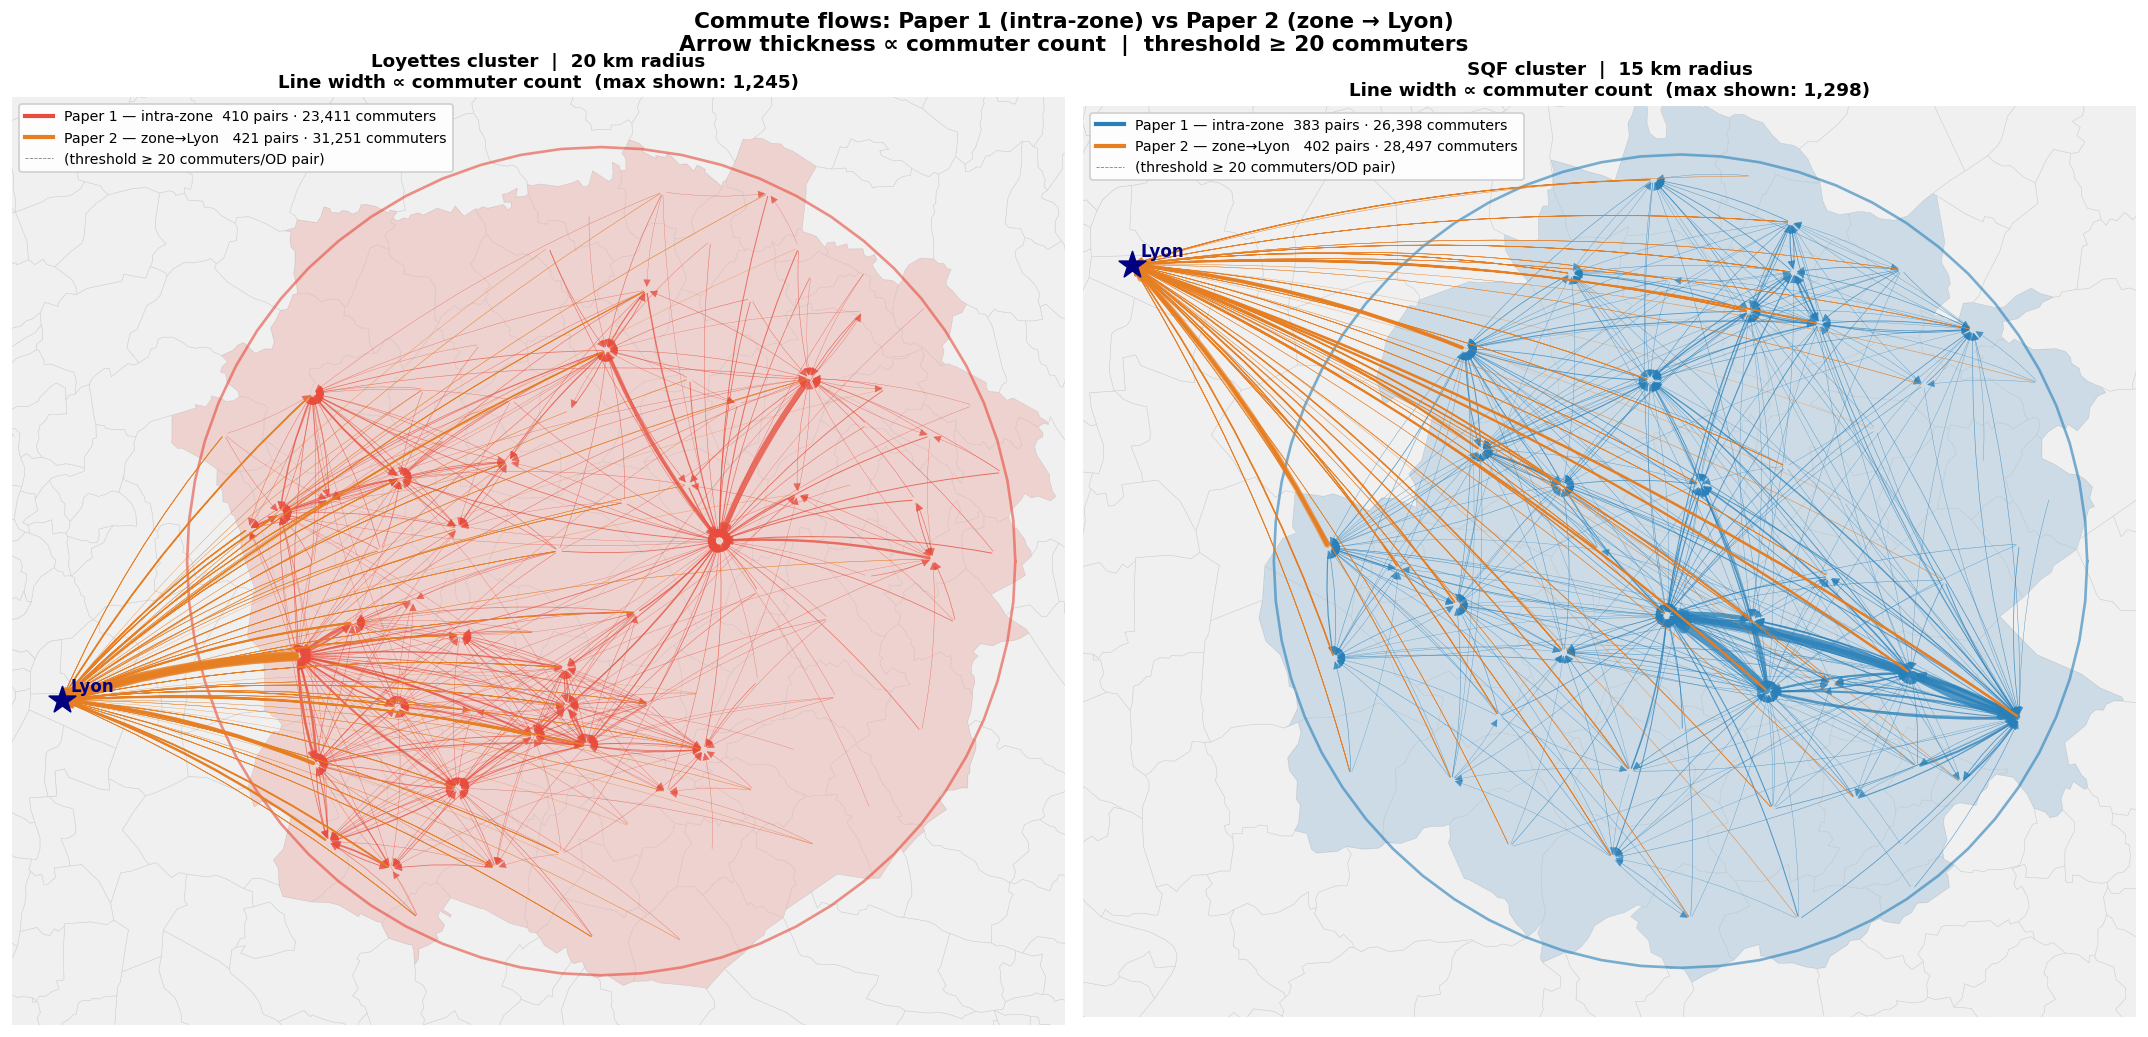

In [102]:
STUDY_RADII   = {"NE — Loyettes": 20, "SE — SQF": 15}
MIN_FLOW      = 20  # draw only OD pairs with ≥ this many commuters
LW_MIN, LW_MAX = 0.1, 6.0  # line-width range; linear ∝ commuter count

from shapely.geometry import Point as _P, box as _box
from matplotlib.lines import Line2D

lc2154 = lyon_communes.to_crs("EPSG:2154").copy()
lc2154["cx"] = lc2154.geometry.centroid.x
lc2154["cy"] = lc2154.geometry.centroid.y
centroid_xy = dict(zip(lc2154["code"], zip(lc2154["cx"], lc2154["cy"])))

lyon_pt2154 = gpd.GeoSeries([_P(LYON_CENTRE_LON, LYON_CENTRE_LAT)], crs="EPSG:4326").to_crs("EPSG:2154").iloc[0]
LYON_XY = (lyon_pt2154.x, lyon_pt2154.y)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, (name, r_km) in zip(axes, STUDY_RADII.items()):
    info       = cluster_info[name]
    in_zone    = set(lyon_communes.loc[lyon_communes[info["dist_col"]] <= r_km, "code"])
    local_zone = in_zone - lyon_zone_codes

    od_p1 = od_mode[
        od_mode["origin"].isin(local_zone) & od_mode["dest"].isin(local_zone)
        & (od_mode["total"] >= MIN_FLOW)
    ]
    od_p2 = od_mode[
        od_mode["origin"].isin(local_zone) & od_mode["dest"].isin(lyon_zone_codes)
        & (od_mode["total"] >= MIN_FLOW)
    ]

    # ── Zoom extent ───────────────────────────────────────────────────────
    cx2154, cy2154 = (
        gpd.GeoSeries([_P(info["clon"], info["clat"])], crs="EPSG:4326")
        .to_crs("EPSG:2154").iloc[0].coords[0]
    )
    pad   = r_km * 1000 * 0.12
    x_min = min(cx2154 - r_km * 1000, LYON_XY[0]) - pad
    x_max = max(cx2154 + r_km * 1000, LYON_XY[0]) + pad
    y_min = min(cy2154 - r_km * 1000, LYON_XY[1]) - pad
    y_max = max(cy2154 + r_km * 1000, LYON_XY[1]) + pad

    view_box = _box(x_min, y_min, x_max, y_max)
    lc_vis   = lc2154[lc2154.geometry.intersects(view_box)]
    lc_vis.plot(ax=ax, color="#f0f0f0", edgecolor="#d0d0d0", linewidth=0.3)
    lc_vis[lc_vis["code"].isin(local_zone)].plot(
        ax=ax, color=info["color"], alpha=0.18, edgecolor="white", linewidth=0.3
    )
    ax.plot(*_P(cx2154, cy2154).buffer(r_km * 1000).boundary.xy,
            color=info["color"], linewidth=1.6, alpha=0.6)

    # ── Linear line-width scale: lw ∝ commuter count ─────────────────────
    # Reference = max flow across both sets so P1 and P2 are on the same scale
    all_shown = pd.concat([od_p1["total"], od_p2["total"]])
    ref_flow  = all_shown.max() if len(all_shown) else 1.0

    def _lw(flow):
        return LW_MIN + (LW_MAX - LW_MIN) * (flow / ref_flow)

    # Paper 1 — intra-zone (sort ascending so large flows render on top)
    for _, row in od_p1.sort_values("total").iterrows():
        o = centroid_xy.get(row["origin"])
        d = centroid_xy.get(row["dest"])
        if o and d:
            ax.annotate(
                "", xy=d, xytext=o,
                arrowprops=dict(arrowstyle="-|>", color=info["color"],
                                lw=_lw(row["total"]), alpha=0.75,
                                connectionstyle="arc3,rad=0.07"),
            )

    # Paper 2 — zone → Lyon (sort ascending, large on top)
    for _, row in od_p2.sort_values("total").iterrows():
        o = centroid_xy.get(row["origin"])
        if o:
            ax.annotate(
                "", xy=LYON_XY, xytext=o,
                arrowprops=dict(arrowstyle="-|>", color="#e67e22",
                                lw=_lw(row["total"]), alpha=0.65,
                                connectionstyle="arc3,rad=0.07"),
            )

    ax.scatter(*LYON_XY, marker="*", s=280, c="navy", zorder=12)
    ax.annotate("Lyon", LYON_XY, xytext=(5, 5), textcoords="offset points",
                fontsize=10, color="navy", fontweight="bold")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_axis_off()

    # Legend with actual commuter counts
    p1_total = od_p1["total"].sum()
    p2_total = od_p2["total"].sum()
    legend_els = [
        Line2D([0],[0], color=info["color"], lw=2.5,
               label=f"Paper 1 — intra-zone  {len(od_p1)} pairs · {p1_total:,.0f} commuters"),
        Line2D([0],[0], color="#e67e22",      lw=2.5,
               label=f"Paper 2 — zone→Lyon   {len(od_p2)} pairs · {p2_total:,.0f} commuters"),
        Line2D([0],[0], color="grey", lw=0.5, linestyle="--",
               label=f"(threshold ≥ {MIN_FLOW:,} commuters/OD pair)"),
    ]
    ax.legend(handles=legend_els, loc="upper left", fontsize=8.5, framealpha=0.93)
    ax.set_title(
        f"{name.split('—')[1].strip()} cluster  |  {r_km} km radius\n"
        f"Line width ∝ commuter count  (max shown: {ref_flow:,.0f})",
        fontsize=11, fontweight="bold",
    )

fig.suptitle(
    "Commute flows: Paper 1 (intra-zone) vs Paper 2 (zone → Lyon)\n"
    f"Arrow thickness ∝ commuter count  |  threshold ≥ {MIN_FLOW:,} commuters",
    fontsize=13, fontweight="bold",
)
fig.tight_layout()
out_arrows = HERE / "output" / "paper1_paper2_arrow_map.png"
fig.savefig(out_arrows, dpi=150, bbox_inches="tight")
print(f"saved {out_arrows}")
print(f"\nOD pairs shown (≥{MIN_FLOW} commuters):")
for name, r_km in STUDY_RADII.items():
    info = cluster_info[name]
    in_zone = set(lyon_communes.loc[lyon_communes[info["dist_col"]] <= r_km, "code"])
    local_zone = in_zone - lyon_zone_codes
    p1 = od_mode[od_mode["origin"].isin(local_zone) & od_mode["dest"].isin(local_zone) & (od_mode["total"] >= MIN_FLOW)]
    p2 = od_mode[od_mode["origin"].isin(local_zone) & od_mode["dest"].isin(lyon_zone_codes) & (od_mode["total"] >= MIN_FLOW)]
    print(f"  {name}: P1 {len(p1)} pairs ({p1['total'].sum():,.0f}), P2 {len(p2)} pairs ({p2['total'].sum():,.0f})")
plt.show()